# Классификация возрастных групп пользователей «Йети»

- Автор: Евдокимов Александр
- Дата: 06.09.26

---

# Структура проекта

<span style="font-size: 18px;">**Цель проекта:**</span>

Разработать модель многоклассовой классификации, которая по анонимизированным данным о цифровом поведении пользователя определяет его возрастную категорию. Модель должна использовать информацию о посещаемых сайтах, времени активности, взаимодействии с рекламой, глубине просмотра, основном устройстве и использовании облачных сервисов.

<span style="font-size: 18px;">**Задачи проекта:**</span>

В рамках указанной цели необходимо решить задачу многоклассовой классификации. Для ее решения необходимо:

- Подготовка среды и библиотек, а также первичное знакомство с данными.
- Исследовательский анализ данных (EDA).
- Предобработка данных.
- Создание новых признаков, а также их отбор.
- Построение базовой модели.
- Обучение и сравнение нескольких архитектур моделей.
- Подбор гиперпараметров моделей.
- Финальное обучение лучшей модели и оценка её качества.
- Подготовка артефактов модели для внедрения.
- Формирование итогового отчёта и рекомендаций.

<span style="font-size: 18px;">**Требования к работе модели:**</span>

1. Бизнес-требования
    - Многоклассовая классификация пользователей по возрастным категориям.
    - Модель должна определять одну из пяти возрастных групп:
        - `0` - младше 18 лет;
        - `1` - 18–25 лет;
        - `2` - 26–40 лет;
        - `3` - 41–55 лет;
        - `4` - 56+ лет.
    - Основная бизнес-задача - определять целевую возрастную аудиторию для последующего использования в рекламном таргетинге.
    - Особое внимание необходимо уделить ошибкам классификации несовершеннолетних пользователей, поскольку переоценка их возраста может привести к нарушению возрастных ограничений при показе рекламы.

2. Метрики оценки
    - Основная: F1-мера с macro-усреднением.
    - Дополнительные: Precision и Recall с macro-усреднением.
    - Оценка должна проводиться отдельно по каждой возрастной категории, чтобы качество модели не определялось только наиболее многочисленными классами.
    - Минимальное требование к качеству лучшей модели: F1 macro не менее 0.75 как на кросс-валидации обучающей выборки, так и на тестовой выборке.

3. Модель
    - Тип задачи: многоклассовая классификация.
    - Основные модели:
        - `LogisticRegression`;
        - `SVC` с линейным ядром;
        - `SVC` с нелинейным ядром.
    - Базовый уровень: `DummyClassifier`.
    - Для каждой архитектуры необходимо подобрать оптимальные гиперпараметры.

4. Создание и отбор признаков
    - Агрегация данных из нескольких таблиц по `user_id`.
    - Формирование признаков на основе истории посещений сайтов.
    - Представление категорий сайтов в виде отдельных признаков.
    - Расчёт доли интернет-активности пользователя по категориям сайтов.
    - Расчёт активности пользователя по времени суток.
    - Определение наиболее активного времени суток.
    - Расчёт среднего количества сессий пользователя в день.
    - Использование информации об активности пользователя в рекламе.
    - Использование характеристик основного устройства пользователя.
    - Использование признака обращения к облачным ресурсам.
    - Применение методов отбора признаков для исключения малоинформативных и избыточных признаков.

5. Разделение и валидация
    - Разделение данных на обучающую-валидационную и тестовую выборки по пользователям.
    - Один и тот же `user_id` не должен встречаться одновременно в обучающей и тестовой выборках.
    - Размер тестовой выборки: от 20% до 30% уникальных пользователей.
    - При разделении необходимо использовать стратификацию по целевой переменной.
    - Для оценки моделей на обучающей выборке использовать кросс-валидацию со стратификацией.
    - Все операции предобработки должны выполняться внутри соответствующих пайплайнов, чтобы избежать утечки данных.

6. Анализ результатов
    - Сравнение качества базовой и основных моделей.
    - Сравнение моделей по F1 macro, Precision macro и Recall macro.
    - Анализ качества классификации отдельно по возрастным категориям.
    - Анализ матрицы ошибок лучшей модели.
    - Выявление возрастных групп, которые модель определяет лучше и хуже остальных.
    - Сравнение результатов на кросс-валидации и тестовой выборке.
    - Оценка соответствия модели установленному порогу качества.

7. Подготовка к внедрению
    - Сохранение итоговой модели.
    - Сохранение пайплайна предобработки.
    - Сохранение функции объединения исходных таблиц и создания признакового пространства.
    - Использование `pickle` или `joblib`.
    - Загрузка сохранённых артефактов и проверка возможности получения предсказаний.
    - Проверка совпадения результатов модели до и после сохранения.

8. Воспроизводимость
    - Фиксировать `random_state` во всех алгоритмах, где это возможно.
    - Вынести основные параметры проекта в отдельные константы.
    - Зафиксировать версии используемых библиотек.

<span style="font-size: 18px;">**Описание данных**</span>

Данные представлены в нескольких CSV-файлах, полученных из разных источников. Основная задача предварительной обработки - исследовать все доступные таблицы, определить связи между ними и объединить информацию в единое признаковое пространство по идентификатору пользователя `user_id`.

<span style="font-size: 18px;">**Таблица `users`**</span>

Таблица `ds_s13_users.csv` содержит целевую переменную:

- `user_id`: уникальный идентификатор пользователя;
- `age_category`: возрастная категория пользователя, которую необходимо предсказывать.


<span style="font-size: 18px;">**Таблица `visits`**</span>

Таблица `ds_s13_visits.csv` содержит логи посещения сайтов пользователями.

Признаки:

- `date` - дата посещения сайта;
- `daytime` - анонимизированное время посещения сайта: {`утро`, `день`, `вечер`, `ночь`};
- `session_id` - уникальный идентификатор сессии;
- `user_id` - уникальный идентификатор пользователя;
- `website_category` - анонимизированная категория посещённого сайта.

На основе данной таблицы можно сформировать дополнительные признаки, характеризующие цифровое поведение пользователя: предпочтения по категориям сайтов, частоту посещений, количество сессий, активность по времени суток и другие характеристики.

<span style="font-size: 18px;">**Таблица `ads_activity`**</span>

Таблица `ads_activity.csv` содержит информацию о взаимодействии пользователя с рекламными объявлениями:

- `user_id` - уникальный идентификатор пользователя;
- `ads_activity` - характеристика активности пользователя при взаимодействии с рекламой: {`очень редко`, `редко`, `умеренно`, `часто`, `очень часто`}.

Признак отражает уровень рекламной активности пользователя и может быть связан с его возрастной категорией.

<span style="font-size: 18px;">**Таблица `surf_depth`**</span>

Таблица `surf_depth.csv` содержит информацию о глубине просмотра сайтов:

- `user_id` - уникальный идентификатор пользователя;
- `surf_depth` - категория глубины переходов пользователя по сайтам во время одной сессии {`поверхностно`, `средне`, `глубоко`}.

<span style="font-size: 18px;">**Таблица `primary_device`**</span>

Таблица `primary_device.csv` содержит информацию об основном устройстве пользователя:

- `user_id` - уникальный идентификатор пользователя;
- `primary_device` - тип основного устройства, используемого пользователем для выхода в интернет.

<span style="font-size: 18px;">**Таблица `cloud_usage`**</span>

Таблица `cloud_usage.csv` содержит информацию об использовании облачных ресурсов:

- `user_id` - уникальный идентификатор пользователя;
- `cloud_usage` - бинарный признак обращения пользователя к облачным ресурсам.

<span style="font-size: 18px;">**Дополнительная информация по данным**</span>

- *Формат данных.* Данные представлены в нескольких CSV-файлах, полученных из разных источников.
- *Связь таблиц.* Основным ключом для объединения пользовательских данных является `user_id`.
- *Целевая переменная.* Целевая переменная `age_category` содержится только в таблице `users`.
- *Анонимизация.* Категории сайтов и другие признаки представлены в анонимизированном виде. Это ограничивает содержательную интерпретацию отдельных категорий, но не препятствует их использованию в качестве признаков модели.
- *Логи посещений.* Таблица `visits` содержит несколько записей для одного пользователя, поэтому перед обучением модели необходимо агрегировать информацию на уровень пользователя.
- *Полнота данных.* В отдельных таблицах могут отсутствовать записи для некоторых пользователей. Такие ситуации необходимо исследовать и корректно обрабатывать на этапе предобработки.
- *Утечка данных.* При формировании признаков и разделении выборок необходимо исключить попадание информации одного и того же пользователя одновременно в обучающую и тестовую выборки.

---

# План работы 

<span style="font-size: 18px;"></span> <a id='contents'></a>

1. [Подготовка среды и библиотек](#p1)
2. Исследовательский анализ данных (EDA)
    - [Объединение датафреймов](#p2a)
    - [Проверка на выбросы](#p2b)
    - [Корреляция](#p2c)
    - [Выводы по EDA](#p2d)
3. [Предобработка данных](#p3)
4. Обучение и оценка моделей
    - [`DummyClassifier`](#p4a)
    - [`LogisticRegression`](#p4b)
    - [`SVC` с линейным ядром](#p4c)
    - [`SVC` с нелинейным ядром](#p4d)
    - [Выводы](#p4e)
5. Создание и отбор признаков
    - [Методы обертки](#p5a)
    - [Отбор через L1-регуляризацию](#p5b)
    - [Вывод](#p5c)
6. Подбор гиперпараметров моделей
    - [Гиперпараметры](#p6a)
    - [Финальная модель](#p6b)
7. [Подготовка артефактов модели](#p7)
8. [Выводы о результатах работы](#p8)

---

<a id='p1'></a>

## Подготовка среды и библиотек

In [1]:
# Установка библиотек
# !pip install phik -U
# !pip install category_encoders
# !pip install mlxtend

# Запись требований в файл (для версии на Git)
# !pip freeze > "../requirements.txt"

# Запись требований в файл (для версии на платформе)
# !pip freeze > "requirements.txt"

In [2]:
# Основные библиотеки для работы с датафреймами, визуализацией, а также вспомогательные
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
from time import time

# Оценка корреляции
from phik import phik_matrix
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Для работы с выборками
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Отбор признаков
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFE

# Классификаторы или модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Многоклассовая классификация
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier

# Предобработка и пайплайн
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,FunctionTransformer,OrdinalEncoder
from sklearn.impute import SimpleImputer

# Поиск гиперпараметров
from sklearn.model_selection import GridSearchCV

# Метрики
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
# Фиксирую состояние и дополнительный класс для более качественного вывода
random_state = 42
class color:
    """
    Класс для форматирования текста в терминале
    """

    PURPLE = "\033[95m"
    CYAN = "\033[96m"
    DARKCYAN = "\033[36m"
    BLUE = "\033[94m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED = "\033[91m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    END = "\033[0m"  # сбросить все стили (возврат к нормальному виду)

In [4]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/ds_s13_users.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/ds_s13_users.csv')

print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,age_category
5579,a8f0-f933905d6ff0b9bae3a2-3a3a3724,2
3443,b70a-08d3d666d67cac77b2bd-e05668a3,4
2351,0217-17b504a06ce90f0c0441-ce7e7aa2,0
4456,4cb5-dab4a264128abc168ba4-2fd3db42,4
2742,a129-2122c6c26184ffd5eeed-b6d7eca9,4



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB

Дополнительная информация по датасету:



,age_category
count,5913.000000
mean,2.441569
std,1.380322
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000


In [5]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/ds_s13_visits.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/ds_s13_visits.csv')

print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,date,daytime,session_id,user_id,website_category
819713,2025-11-11,ночь,44ec8831-483a-49c1-b624-da905b2c5a48,8b5a-e02fa27da5d4ef64fa0e-e9d1015b,Category 05
113905,2025-11-02,день,16d9a4bd-427d-4ab4-a209-af367ebfdcfa,5ce7-a1b477d64082aa9da183-148252ca,Category 14
675182,2025-11-09,утро,48668067-7597-4a26-806c-9615b1c748ea,50f2-60df5a329078d0d35392-6cba3d0e,Category 14
13370,2025-11-01,вечер,3fc800b7-9d11-4b65-a6a8-db7173e4b0a4,7b70-59e71dec65aa1c43b412-ee75f54b,Category 16
2567,2025-11-01,вечер,5201f9fe-bb07-4790-b0fe-0dcc71e8137f,17e4-5b812913d467d9afbe43-241fa410,Category 19



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB

Дополнительная информация по датасету:



,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,404c2438-7a91-4537-bd77-8ea6a14b34ec,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


In [6]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/ads_activity.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/ads_activity.csv')

print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,ads_activity
4071,a3bd-a1510472fd7044805cf2-583682be,очень редко
4880,d510-64cd40717a2e439bd023-51bb7138,часто
1121,8102-583e14edf51b9c39aa5b-a89bbf67,умеренно
561,2d75-11d28eb09a700d17a0af-cfd1a4b8,часто
1188,0d4d-f2550f2d528ed6008ad1-7a643f75,умеренно



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB

Дополнительная информация по датасету:



,user_id,ads_activity
count,5826,5826
unique,5593,5
top,35cd-a972339dec534f49332c-a8b6d383,умеренно
freq,2,1897


In [7]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/surf_depth.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/surf_depth.csv')

print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,surf_depth
5122,4f76-d4c5870763b6621aedb0-a2fed726,поверхностно
5531,6a1a-c1d886343795dcc81db2-bb190778,средне
2445,526c-ca155433b0608bbba287-50cad9fb,поверхностно
2259,3839-fda9897dcde9bc940bbe-4be2f840,средне
1765,24d0-68235ddde66a1567f107-cf598344,средне



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB

Дополнительная информация по датасету:



,user_id,surf_depth
count,5715,5715
unique,5715,3
top,f238-0c4c1e787cce311541b7-736925a0,средне
freq,1,2435


In [8]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/primary_device.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/primary_device.csv')


print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,primary_device
3528,48a6-050e5e781e59929619af-11a3da6d,смартфон
5359,4b53-62b04b2f385984220447-38b138d5,ПК
1858,f6c1-dfc8cf4fc5bb08cb4d5e-e5507f27,смартфон
2523,50f2-60df5a329078d0d35392-6cba3d0e,смартфон
4412,75f8-0c02dc0aa940635f887c-7b62ebfe,ПК



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB

Дополнительная информация по датасету:



,user_id,primary_device
count,5669,5669
unique,5669,4
top,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
freq,1,3083


In [9]:
try:
    # Локальная версия (Git)
    df_init = pd.read_csv('../datasets/cloud_usage.csv')
except FileNotFoundError:
    # Версия на платформе
    df_init = pd.read_csv('/datasets/cloud_usage.csv')

print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,cloud_usage
1129,121e-e99f4e586ac5ef0f70ae-56942d61,False
932,b417-56f0dd32466b3aec2526-732fa6b0,False
1780,aca6-430119148080c8e8fb8d-506c6b35,False
3764,75ad-4c909d13c2caa3ef8fb7-3fc99077,True
4962,678f-937e81056dcb00d69d25-be218491,False



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB

Дополнительная информация по датасету:



,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


<a id='p2a'></a>

---

## Исследовательский анализ данных

### Объединение датафреймов

Последовательно соединим датафреймы в один. Начнем с `ds_s13_users.csv`, содержащий целевую переменную `age_category`. Для него проверим наличие дубликатов по `user_id` (явных пропусков нет ни в одном датафрейме), а также проанализируем баланс классов целевой переменной. С остальными датафреймами работа будет выполнятся по следующему алгоритму:
1. Проверяем на дубликаты по `user_id` и на неявные дубликаты по остальным столбцам. Если имеются, то в зависимости от датафрейма принимаем соответствующие решения.
2. Если необходимо, то вводим новые признаки и агрегируем данные по `user_id`.
3. Используем левое соединение  (слева датафрейм с целевой переменной) и к датафрейму с целевой переменной присоединяем новый датафрейм.
4. Проверяем полученный новый датафрейм на пропуски (могут образоваться из-за левого соединения) и принимаем решение, как их обработать (заполнить флагом, медианой или удалить строку (последние будет применять только в крайнем случае)).
5. Повторяем шаги 2-4 пока не переберем все датафреймы.

Автоматизировать процесс может быть неправильным решением, т.к. возможны неявные дубликаты, которые не ясно заранее как интерпретировать и заполнять. Ниже приводится отдельно по каждому датафрейму процесс обработки.

[К Содержимому проекта](#contents)

---

#### `ds_s13_users`

In [10]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/ds_s13_users.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/ds_s13_users.csv')

print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)

print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + f'Колонка age_category:\n'  + color.END,df_read['age_category'].unique())


Общее количество строк: 5913
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5826
1,age_category,5


Колонка age_category:
 [4 2 0 1 3]


Есть дубликаты по `user_id`, проверим их.

In [11]:
display(df_read[df_read.duplicated(subset=['user_id'], keep=False)].sort_values(by=['user_id'], ascending=False))

,user_id,age_category
3654,f971-dd06125602bf086b1233-db453f75,2
3828,f971-dd06125602bf086b1233-db453f75,2
2086,f8d3-f0747e08cdab49a64658-40748253,3
5630,f8d3-f0747e08cdab49a64658-40748253,3
1479,f541-32493ee668694a72068d-724d6766,2
...,...,...
577,041d-48afbfadf1b0387c77a8-14776807,2
1554,036b-a85efa206bd9e9d86fa8-20152d7f,4
317,036b-a85efa206bd9e9d86fa8-20152d7f,4
5218,0217-17b504a06ce90f0c0441-ce7e7aa2,0


In [12]:
display(df_read[df_read.duplicated(subset=['user_id','age_category'], keep=False)].sort_values(by=['user_id'], ascending=False))

,user_id,age_category
3654,f971-dd06125602bf086b1233-db453f75,2
3828,f971-dd06125602bf086b1233-db453f75,2
2086,f8d3-f0747e08cdab49a64658-40748253,3
5630,f8d3-f0747e08cdab49a64658-40748253,3
1479,f541-32493ee668694a72068d-724d6766,2
...,...,...
577,041d-48afbfadf1b0387c77a8-14776807,2
1554,036b-a85efa206bd9e9d86fa8-20152d7f,4
317,036b-a85efa206bd9e9d86fa8-20152d7f,4
5218,0217-17b504a06ce90f0c0441-ce7e7aa2,0


Дубликаты явные (повторяет и age_category), удалим их:

In [13]:
df_init = df_read.drop_duplicates(subset=['user_id','age_category'],ignore_index=True)

Визуализируем распределение классов:

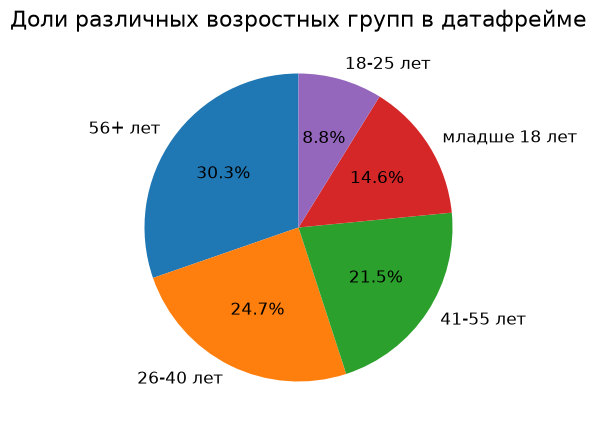

In [14]:
grouped = df_init.groupby('age_category').agg({'user_id':'count'}).sort_values(by = 'user_id',ascending=False)
age_labels = {
    0: 'младше 18 лет',
    1: '18-25 лет',
    2: '26-40 лет',
    3: '41-55 лет',
    4: '56+ лет'
}
grouped.index = grouped.index.map(age_labels)
grouped = grouped.rename(columns={'user_id': 'Доля'})
grouped['Доля'] = round(100*grouped['Доля']/sum(grouped['Доля']),2)

fig = grouped['Доля'].plot.pie(figsize = (5,5),autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': 'black'})

plt.title('Доли различных возростных групп в датафрейме', fontsize=16)
plt.ylabel('')
plt.show()

Наблюдается дисбаланс классов, однако, самая критичная группа - несовершеннолетние не является минимальным, классом. Минимальная группа: 18-25, а максимальная - 56+.

---

#### `ds_s13_visits`

In [15]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/ds_s13_visits.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/ds_s13_visits.csv')

In [16]:
print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)

print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))


Общее количество строк: 1065745
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,session_id,1049995
1,user_id,5826
2,website_category,20
3,date,14
4,daytime,4


Заметны дубликаты по `session_id`, проверим, являются они явными или есть различные поля.

In [17]:
display(df_read[df_read.duplicated(subset=['session_id'], keep=False)].sort_values(by=['user_id','date','daytime'], ascending=False))

,date,daytime,session_id,user_id,website_category
1050857,2025-11-14,ночь,d7528b1f-5320-455d-a189-5926effc2c68,ffbf-71c28263b860736010d4-a0ee88f3,Category 13
1050858,2025-11-14,ночь,d7528b1f-5320-455d-a189-5926effc2c68,ffbf-71c28263b860736010d4-a0ee88f3,Category 13
685335,2025-11-09,утро,222e24f7-f8b0-432b-94b9-c5a6b3f17cc0,ffbf-71c28263b860736010d4-a0ee88f3,Category 17
685336,2025-11-09,утро,222e24f7-f8b0-432b-94b9-c5a6b3f17cc0,ffbf-71c28263b860736010d4-a0ee88f3,Category 17
407948,2025-11-06,вечер,f4a6d7d1-4be0-4acd-8660-4a49cf1e1666,ffbf-71c28263b860736010d4-a0ee88f3,Category 08
...,...,...,...,...,...
255927,2025-11-04,день,8b48cdff-e5a5-4280-92c8-9145de188e08,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 07
103374,2025-11-02,день,593d233c-65de-4fbd-a9da-e5d8e75c1d8e,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 11
103375,2025-11-02,день,593d233c-65de-4fbd-a9da-e5d8e75c1d8e,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 11
60928,2025-11-01,утро,20a407f7-1081-4acc-9cf1-b6a286715be5,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 08


In [18]:
display(df_read[df_read.duplicated(keep=False)].sort_values(by=['user_id','date','daytime'], ascending=False))

,date,daytime,session_id,user_id,website_category
1050857,2025-11-14,ночь,d7528b1f-5320-455d-a189-5926effc2c68,ffbf-71c28263b860736010d4-a0ee88f3,Category 13
1050858,2025-11-14,ночь,d7528b1f-5320-455d-a189-5926effc2c68,ffbf-71c28263b860736010d4-a0ee88f3,Category 13
685335,2025-11-09,утро,222e24f7-f8b0-432b-94b9-c5a6b3f17cc0,ffbf-71c28263b860736010d4-a0ee88f3,Category 17
685336,2025-11-09,утро,222e24f7-f8b0-432b-94b9-c5a6b3f17cc0,ffbf-71c28263b860736010d4-a0ee88f3,Category 17
407948,2025-11-06,вечер,f4a6d7d1-4be0-4acd-8660-4a49cf1e1666,ffbf-71c28263b860736010d4-a0ee88f3,Category 08
...,...,...,...,...,...
255927,2025-11-04,день,8b48cdff-e5a5-4280-92c8-9145de188e08,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 07
103374,2025-11-02,день,593d233c-65de-4fbd-a9da-e5d8e75c1d8e,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 11
103375,2025-11-02,день,593d233c-65de-4fbd-a9da-e5d8e75c1d8e,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 11
60928,2025-11-01,утро,20a407f7-1081-4acc-9cf1-b6a286715be5,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 08


Дубликаты явные (повторяются все поля), удалим их:

In [19]:
df_read = df_read.drop_duplicates(subset=['session_id'],ignore_index=True)

После удаления выполним агрегацию по `user_id`. При выполнении агрегации и создании новых столбцов возможно возникновение сильных корреляций, поэтому обязательно будет выполнена проверка на корреляцию. Создадим следующие столбцы:
- `total_sessions` - общее число сессий за 14 дней.
- `active_days` - временный рабочий столбец, который будет удален после выполнения необходимых с его помощью преобразований. Считает сколько дней пользователь присутствовал в сети.
- `active_share` - доля дней, в которых пользователь проявлял активность в сети. На мой взгляд более сильный кандидат по сравнению с `active_days`, т.к. показывает долю, а не конкретное абсолютное число, которое зависит от периода анализа (а он маленький). 
- `sessions_per_day`:  `sessions_per_day = total_sessions / active_days` - среднее число сессий в день.
- `unique_categories` - число разных категорий, посещённых пользователем, временный столбец, который будет удален.
- `sessions_per_category`: `sessions_per_category = total_sessions / unique_categories` - среднее число сессий на одну категорию.
- `most_freq_cat`, `least_freq_cat` - наиболее и наименее часто посещаемые категории (возможно важно как самая первая, так и самая последняя категории по посещаемости).
- `share_most_freq_cat`, `share_least_freq_cat` - доли по количеству сессий наиболее и наименее часто посещаемых категорий.
- `share_daytime_morn`, `share_daytime_sun`, `share_daytime_evening`, `share_daytime_night` - доли посещений утром, днем, вечером и ночью соответственно.
- `most_daytime`, `least_daytime` - название частей дня, в которые наиболее и наименее часто пользователи подключаются к сайтам.

In [20]:
def aggregate_visits(visits):
    df = visits.copy()
    
    total_days = df['date'].nunique()
    
    agg = df.groupby('user_id').agg(
        total_sessions=('session_id', 'count'),
        active_days=('date', 'nunique'),
        unique_categories=('website_category', 'nunique')
    ).reset_index()
    
    # Таблица с количеством сессий по временам суток (до деления на общее количество)
    daytime_counts = df.pivot_table(
        index='user_id', 
        columns='daytime', 
        values='session_id', 
        aggfunc='count', 
        fill_value=0
    )
    
    # Доли сессий по временам суток
    total_session_per_user = df.groupby('user_id')['session_id'].count()
    daytime = daytime_counts.div(total_session_per_user, axis=0)
    daytime = daytime.rename(columns={
        'утро': 'share_daytime_morn',
        'день': 'share_daytime_sun',
        'вечер': 'share_daytime_evening',
        'ночь': 'share_daytime_night'
    }).reset_index()
    
    # Определяем most_daytime и least_daytime на основе количеств
    most_daytime = daytime_counts.idxmax(axis=1).rename('most_daytime')
    least_daytime = daytime_counts.idxmin(axis=1).rename('least_daytime')
    daytime_stats = pd.DataFrame({
        'most_daytime': most_daytime,
        'least_daytime': least_daytime
    }).reset_index()
    
    cat_session_counts = df.groupby(['user_id', 'website_category'])['session_id'].count().reset_index(name='cat_session_count')
    
    idx_max = cat_session_counts.groupby('user_id')['cat_session_count'].idxmax()
    idx_min = cat_session_counts.groupby('user_id')['cat_session_count'].idxmin()
    
    most_freq = (
        cat_session_counts.loc[idx_max, ['user_id', 'website_category', 'cat_session_count']]
        .rename(columns={'website_category': 'most_freq_cat', 'cat_session_count': 'most_freq_count'})
    )
    least_freq = (
        cat_session_counts.loc[idx_min, ['user_id', 'website_category', 'cat_session_count']]
        .rename(columns={'website_category': 'least_freq_cat', 'cat_session_count': 'least_freq_count'})
    )
    
    result = agg.merge(most_freq, on='user_id', how='left')
    result = result.merge(least_freq, on='user_id', how='left')
    
    result['share_most_freq_cat'] = result['most_freq_count'] / result['total_sessions']
    result['share_least_freq_cat'] = result['least_freq_count'] / result['total_sessions']
    
    result['active_share'] = result['active_days'] / total_days
    result['sessions_per_day'] = result['total_sessions'] / result['active_days']
    result['sessions_per_category'] = result['total_sessions'] / result['unique_categories']
    
    result = result.merge(daytime, on='user_id', how='left')
    result = result.merge(daytime_stats, on='user_id', how='left')
    
    result = result.drop(columns=['active_days', 'unique_categories', 'most_freq_count', 'least_freq_count'])
    
    return result

In [21]:
df_read = aggregate_visits(df_read)

Выведем информацию по итоговому датафрейму:

In [22]:
print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_read.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_read.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_read.describe())


Случайные пять строк:


,user_id,total_sessions,most_freq_cat,least_freq_cat,share_most_freq_cat,share_least_freq_cat,active_share,sessions_per_day,sessions_per_category,share_daytime_evening,share_daytime_sun,share_daytime_night,share_daytime_morn,most_daytime,least_daytime
4071,b417-56f0dd32466b3aec2526-732fa6b0,190,Category 09,Category 04,0.110526,0.010526,1.0,13.571429,10.555556,0.336842,0.389474,0.042105,0.231579,день,ночь
4880,d797-94c3aae9d95b3345893f-275b8f61,209,Category 18,Category 14,0.090909,0.009569,1.0,14.928571,11.000000,0.358852,0.363636,0.081340,0.196172,день,ночь
1121,2f6c-0a8465e79ee4b1092dcb-f3bd52bd,213,Category 13,Category 12,0.126761,0.004695,1.0,15.214286,11.833333,0.394366,0.370892,0.089202,0.145540,вечер,ночь
561,17e9-7be541ee17b3a21c27ac-ecdc68e7,192,Category 07,Category 01,0.083333,0.015625,1.0,13.714286,10.105263,0.510417,0.260417,0.078125,0.151042,вечер,ночь
1188,32c9-d71794b21c5fc09a9521-e3adbd6b,154,Category 05,Category 02,0.123377,0.012987,1.0,11.000000,8.105263,0.376623,0.318182,0.045455,0.259740,вечер,ночь



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                5826 non-null   str    
 1   total_sessions         5826 non-null   int64  
 2   most_freq_cat          5826 non-null   str    
 3   least_freq_cat         5826 non-null   str    
 4   share_most_freq_cat    5826 non-null   float64
 5   share_least_freq_cat   5826 non-null   float64
 6   active_share           5826 non-null   float64
 7   sessions_per_day       5826 non-null   float64
 8   sessions_per_category  5826 non-null   float64
 9   share_daytime_evening  5826 non-null   float64
 10  share_daytime_sun      5826 non-null   float64
 11  share_daytime_night    5826 non-null   float64
 12  share_daytime_morn     5826 non-null   float64
 13  most_daytime           5826 non-null   str    
 14  least_daytime          5826 non-n

,total_sessions,share_most_freq_cat,share_least_freq_cat,active_share,sessions_per_day,sessions_per_category,share_daytime_evening,share_daytime_sun,share_daytime_night,share_daytime_morn
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,180.225712,0.125653,0.011591,0.999902,12.874047,9.729162,0.358199,0.364961,0.078108,0.198733
std,75.186802,0.030683,0.006217,0.002645,5.369733,3.949260,0.048836,0.045206,0.024633,0.038134
min,100.000000,0.069444,0.001536,0.928571,7.142857,5.263158,0.214286,0.217822,0.000000,0.049505
25%,124.000000,0.103753,0.006873,1.000000,8.857143,6.789474,0.324324,0.335058,0.060606,0.172575
50%,167.000000,0.119825,0.009901,1.000000,11.928571,8.947368,0.357542,0.365385,0.076142,0.196765
75%,213.000000,0.140244,0.015152,1.000000,15.214286,11.473684,0.391304,0.395664,0.093407,0.223863
max,839.000000,0.295918,0.039604,1.000000,59.928571,44.157895,0.530000,0.532710,0.198020,0.360000


In [23]:
df_read[df_read['active_share']<1].shape[0]

8

Заметна слабая вариативность столбца `active_share`. Фактически всегда константа - 1. Только 8 пользователей имеют сессии не каждый день. Идея не удачна, удалим и при сборке пайплайна не будем создавать столбец. После этого соединим с исходным датафреймом. Кроме того, `sessions_per_day` также не является удачной идеей, т.к. почти всегда делим на одно и тоже число, а значит линейно зависим от `total_sessions`.

In [24]:
df_read = df_read.drop(columns = ['active_share', 'sessions_per_day'])
df_init = pd.merge(df_init, df_read, on='user_id', how = 'left')

---

#### `ads_activity`

In [25]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/ads_activity.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/ads_activity.csv')

print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + f'Колонка ads_activity:\n'  + color.END,df_read['ads_activity'].unique())


Общее количество строк: 5826
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5593
1,ads_activity,5


Колонка ads_activity:
 <StringArray>
['очень часто', 'редко', 'очень редко', 'умеренно', 'часто']
Length: 5, dtype: str


In [26]:
display(df_read[df_read.duplicated(subset=['user_id'], keep=False)].sort_values(by=['user_id'], ascending=False))

,user_id,ads_activity
4879,fe45-acc4b4d0a63aba2f7efd-da349370,очень редко
3642,fe45-acc4b4d0a63aba2f7efd-da349370,очень редко
2424,fc4b-62b0fec3c90fb70f98f1-5e606a7c,очень редко
5545,fc4b-62b0fec3c90fb70f98f1-5e606a7c,очень редко
3972,fb05-8a3b260e43f8cd2121b2-3ce15903,редко
...,...,...
5663,0501-ba75c2755d55061a096d-d0e8c7db,часто
976,02d4-8707e8f46c6769731dd5-c268adff,очень редко
3481,02d4-8707e8f46c6769731dd5-c268adff,очень редко
5488,0259-a9907d16efbe00c4e18a-ce0364c9,очень часто


In [27]:
display(df_read[df_read.duplicated(keep=False)].sort_values(by=['user_id'], ascending=False))

,user_id,ads_activity
4879,fe45-acc4b4d0a63aba2f7efd-da349370,очень редко
3642,fe45-acc4b4d0a63aba2f7efd-da349370,очень редко
2424,fc4b-62b0fec3c90fb70f98f1-5e606a7c,очень редко
5545,fc4b-62b0fec3c90fb70f98f1-5e606a7c,очень редко
3972,fb05-8a3b260e43f8cd2121b2-3ce15903,редко
...,...,...
5663,0501-ba75c2755d55061a096d-d0e8c7db,часто
976,02d4-8707e8f46c6769731dd5-c268adff,очень редко
3481,02d4-8707e8f46c6769731dd5-c268adff,очень редко
5488,0259-a9907d16efbe00c4e18a-ce0364c9,очень часто


Дубликаты явные (повторяются все поля), удалим их и соединим этот датафрейм с исходным.

In [28]:
df_read = df_read.drop_duplicates(ignore_index=True)
df_init = pd.merge(df_init, df_read, on='user_id', how = 'left')

---

#### `surf_depth`

In [29]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/surf_depth.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/surf_depth.csv')
    
print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + f'Колонка surf_depth:\n'  + color.END,df_read['surf_depth'].unique())


Общее количество строк: 5715
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5715
1,surf_depth,3


Колонка surf_depth:
 <StringArray>
['поверхностно', 'глубоко', 'средне']
Length: 3, dtype: str


Дуликатов нет, значения соответствуют ожиданиям, соединим:

In [30]:
df_init = pd.merge(df_init, df_read, on='user_id', how = 'left')

---

#### `primary_device`

In [31]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/primary_device.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/primary_device.csv')
    
print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + f'Колонка primary_device:\n'  + color.END,df_read['primary_device'].unique())


Общее количество строк: 5669
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5669
1,primary_device,4


Колонка primary_device:
 <StringArray>
['смартфон', 'ПК', 'ноутбук', 'планшет']
Length: 4, dtype: str


Дуликатов нет, значения соответствуют ожиданиям, соединим:

In [32]:
df_init = pd.merge(df_init, df_read, on='user_id', how = 'left')

---

#### `cloud_usage`

In [33]:
try:
    # Локальная версия (Git)
    df_read = pd.read_csv('../datasets/cloud_usage.csv')
except FileNotFoundError:
    # Версия на платформе
    df_read = pd.read_csv('/datasets/cloud_usage.csv')
    
print(color.BOLD + color.RED + "\nОбщее количество строк: " + str(df_read.shape[0]) + color.END)
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_read.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + f'Колонка cloud_usage:\n'  + color.END,df_read['cloud_usage'].unique())


Общее количество строк: 5680
Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5680
1,cloud_usage,2


Колонка cloud_usage:
 [False  True]


Дуликатов нет, значения соответствуют ожиданиям, соединим:

In [34]:
df_init = pd.merge(df_init, df_read, on='user_id', how = 'left')

---

#### Выводы по итогам сбора в единый датафрейм.

In [35]:
print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_init.sample(n=5, random_state = random_state))
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df_init.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_init.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_init.describe())


Случайные пять строк:


,user_id,age_category,total_sessions,most_freq_cat,least_freq_cat,share_most_freq_cat,share_least_freq_cat,sessions_per_category,share_daytime_evening,share_daytime_sun,share_daytime_night,share_daytime_morn,most_daytime,least_daytime,ads_activity,surf_depth,primary_device,cloud_usage
4071,9218-fbce2c03df068daac0fd-768ae1b2,4,104,Category 13,Category 14,0.192308,0.009615,6.117647,0.298077,0.403846,0.086538,0.211538,день,ночь,очень редко,средне,ПК,True
4880,10d1-90b15978370c1c4e6afb-ec358ce4,0,162,Category 03,Category 10,0.129630,0.006173,9.000000,0.376543,0.382716,0.080247,0.160494,день,ночь,редко,поверхностно,смартфон,False
1121,dae6-9d21643e2dbb5037177e-71d6cc8a,3,158,Category 03,Category 11,0.139241,0.006329,8.315789,0.373418,0.341772,0.075949,0.208861,вечер,ночь,редко,поверхностно,смартфон,True
561,e60c-dd2231fd3b6047892469-5e96a9d7,2,252,Category 05,Category 10,0.119048,0.003968,14.000000,0.388889,0.373016,0.067460,0.170635,вечер,ночь,умеренно,поверхностно,смартфон,True
1188,49f1-3593b1cb88429101d05a-1f0aedc3,2,165,Category 16,Category 01,0.103030,0.018182,8.684211,0.369697,0.345455,0.096970,0.187879,вечер,ночь,редко,средне,смартфон,False


Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,user_id,5826
1,share_daytime_evening,2718
2,share_daytime_sun,2621
3,share_daytime_morn,2472
4,share_most_freq_cat,2118
5,share_daytime_night,1926
6,share_least_freq_cat,911
7,sessions_per_category,768
8,total_sessions,366
9,most_freq_cat,20



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                5826 non-null   str    
 1   age_category           5826 non-null   int64  
 2   total_sessions         5826 non-null   int64  
 3   most_freq_cat          5826 non-null   str    
 4   least_freq_cat         5826 non-null   str    
 5   share_most_freq_cat    5826 non-null   float64
 6   share_least_freq_cat   5826 non-null   float64
 7   sessions_per_category  5826 non-null   float64
 8   share_daytime_evening  5826 non-null   float64
 9   share_daytime_sun      5826 non-null   float64
 10  share_daytime_night    5826 non-null   float64
 11  share_daytime_morn     5826 non-null   float64
 12  most_daytime           5826 non-null   str    
 13  least_daytime          5826 non-null   str    
 14  ads_activity           5593 non-n

,age_category,total_sessions,share_most_freq_cat,share_least_freq_cat,sessions_per_category,share_daytime_evening,share_daytime_sun,share_daytime_night,share_daytime_morn
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,2.440439,180.225712,0.125653,0.011591,9.729162,0.358199,0.364961,0.078108,0.198733
std,1.381287,75.186802,0.030683,0.006217,3.949260,0.048836,0.045206,0.024633,0.038134
min,0.000000,100.000000,0.069444,0.001536,5.263158,0.214286,0.217822,0.000000,0.049505
25%,2.000000,124.000000,0.103753,0.006873,6.789474,0.324324,0.335058,0.060606,0.172575
50%,3.000000,167.000000,0.119825,0.009901,8.947368,0.357542,0.365385,0.076142,0.196765
75%,4.000000,213.000000,0.140244,0.015152,11.473684,0.391304,0.395664,0.093407,0.223863
max,4.000000,839.000000,0.295918,0.039604,44.157895,0.530000,0.532710,0.198020,0.360000


В итоговом датафреймы после сбора информации из разных таблиц получилось 18 столбцов и 5826 строчек, в которых содержится информация по профилям пользователей. Выводы по итогам объединения:
- Замечены дубликаты в датафреймах (все они были явными дубликатами, совпадали все значения) - `ds_s13_users`, `ds_s13_visits`, `ads_activity` до 5% от общего количества строчек.
- Наблюдается дисбаланс классов, однако, самая критичная группа - несовершеннолетние не является минимальным, классом. Минимальная группа: 18-25, а максимальная - 56+.
- Пропуски есть в столбцах `ads_activity`, `surf_depth`, `primary_device` и `cloud_usage`. Они получились после левого соединения с таблицей, содержащей целевую переменную. Первые три являются категориальными признаками, поэтому будет добавлена новая категория - 'неизвестно'. `cloud_usage` - бинарный категориальный признак, его значение разумно заполнить медианным значением.
- Для таблицы `ds_s13_visits` выполнена агрегация и получены следующие столбцы:
    1. `total_sessions` - общее число сессий за 14 дней. 
    2. `sessions_per_category`: `sessions_per_category = total_sessions / unique_categories` - среднее число сессий на одну категорию.
    3. `most_freq_cat`, `least_freq_cat` - наиболее и наименее часто посещаемые категории (возможно важно как самая первая, так и самая последняя категории по посещаемости).
    4. `share_most_freq_cat`, `share_least_freq_cat` - доли по количеству сессий наиболее и наименее часто посещаемых категорий.
    5. `share_daytime_morn`, `share_daytime_sun`, `share_daytime_evening`, `share_daytime_night` - доли посещений утром, днем, вечером и ночью соответственно.
    6.  `most_daytime`, `least_daytime` время дня, в которое у пользователя наибольшее и наименьшее количество сессий.    
    7. Часть идей добавляемых столбцов оказалось неудачной, т.к. `active_days` - количество дней, в которые пользователь подключался к базе почти всегда равен 14 дням, что совпадает с периодом наблюдений, а значит он сам и любые производные от него не являются информативными.
    8. Здесь были введен временный столбец `unique_categories` - количество уникальных категорий сайтов, которые посещал пользователь.
    9. Полученные столбцы не содержат пропуски.
- При кодировании категориальных признаков используем **OneHotEncoder**.
- Также удалим из датафрейма `user_id`, т.к. признак технический и не должен быть связан с целевой переменной.

<a id='p2b'></a>

---

### Проверка на выбросы

Выведем гистограммы для числовых переменных и столбчатые диаграммы для категориальных. 

[К Содержимому проекта](#contents)

In [36]:
def plot_cat_vs_target(df, target_col, exclude_cols=None, figsize=(15, 15), ncols=3):
    cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    
    if exclude_cols:
        cat_cols = [c for c in cat_cols if c not in exclude_cols]
    if target_col in cat_cols:
        cat_cols.remove(target_col)
    
    n_features = len(cat_cols)
    nrows = math.ceil(n_features / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        ctab = pd.crosstab(df[col], df[target_col], dropna=False)
        
        ctab.plot.barh(ax=ax, legend=False)
        ax.set_title(col, fontsize=12)
        ax.set_xlabel('Количество')
        ax.set_ylabel(col)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title=target_col, loc='upper right', bbox_to_anchor=(1.0, 1.0))
    
    plt.tight_layout()
    plt.show()

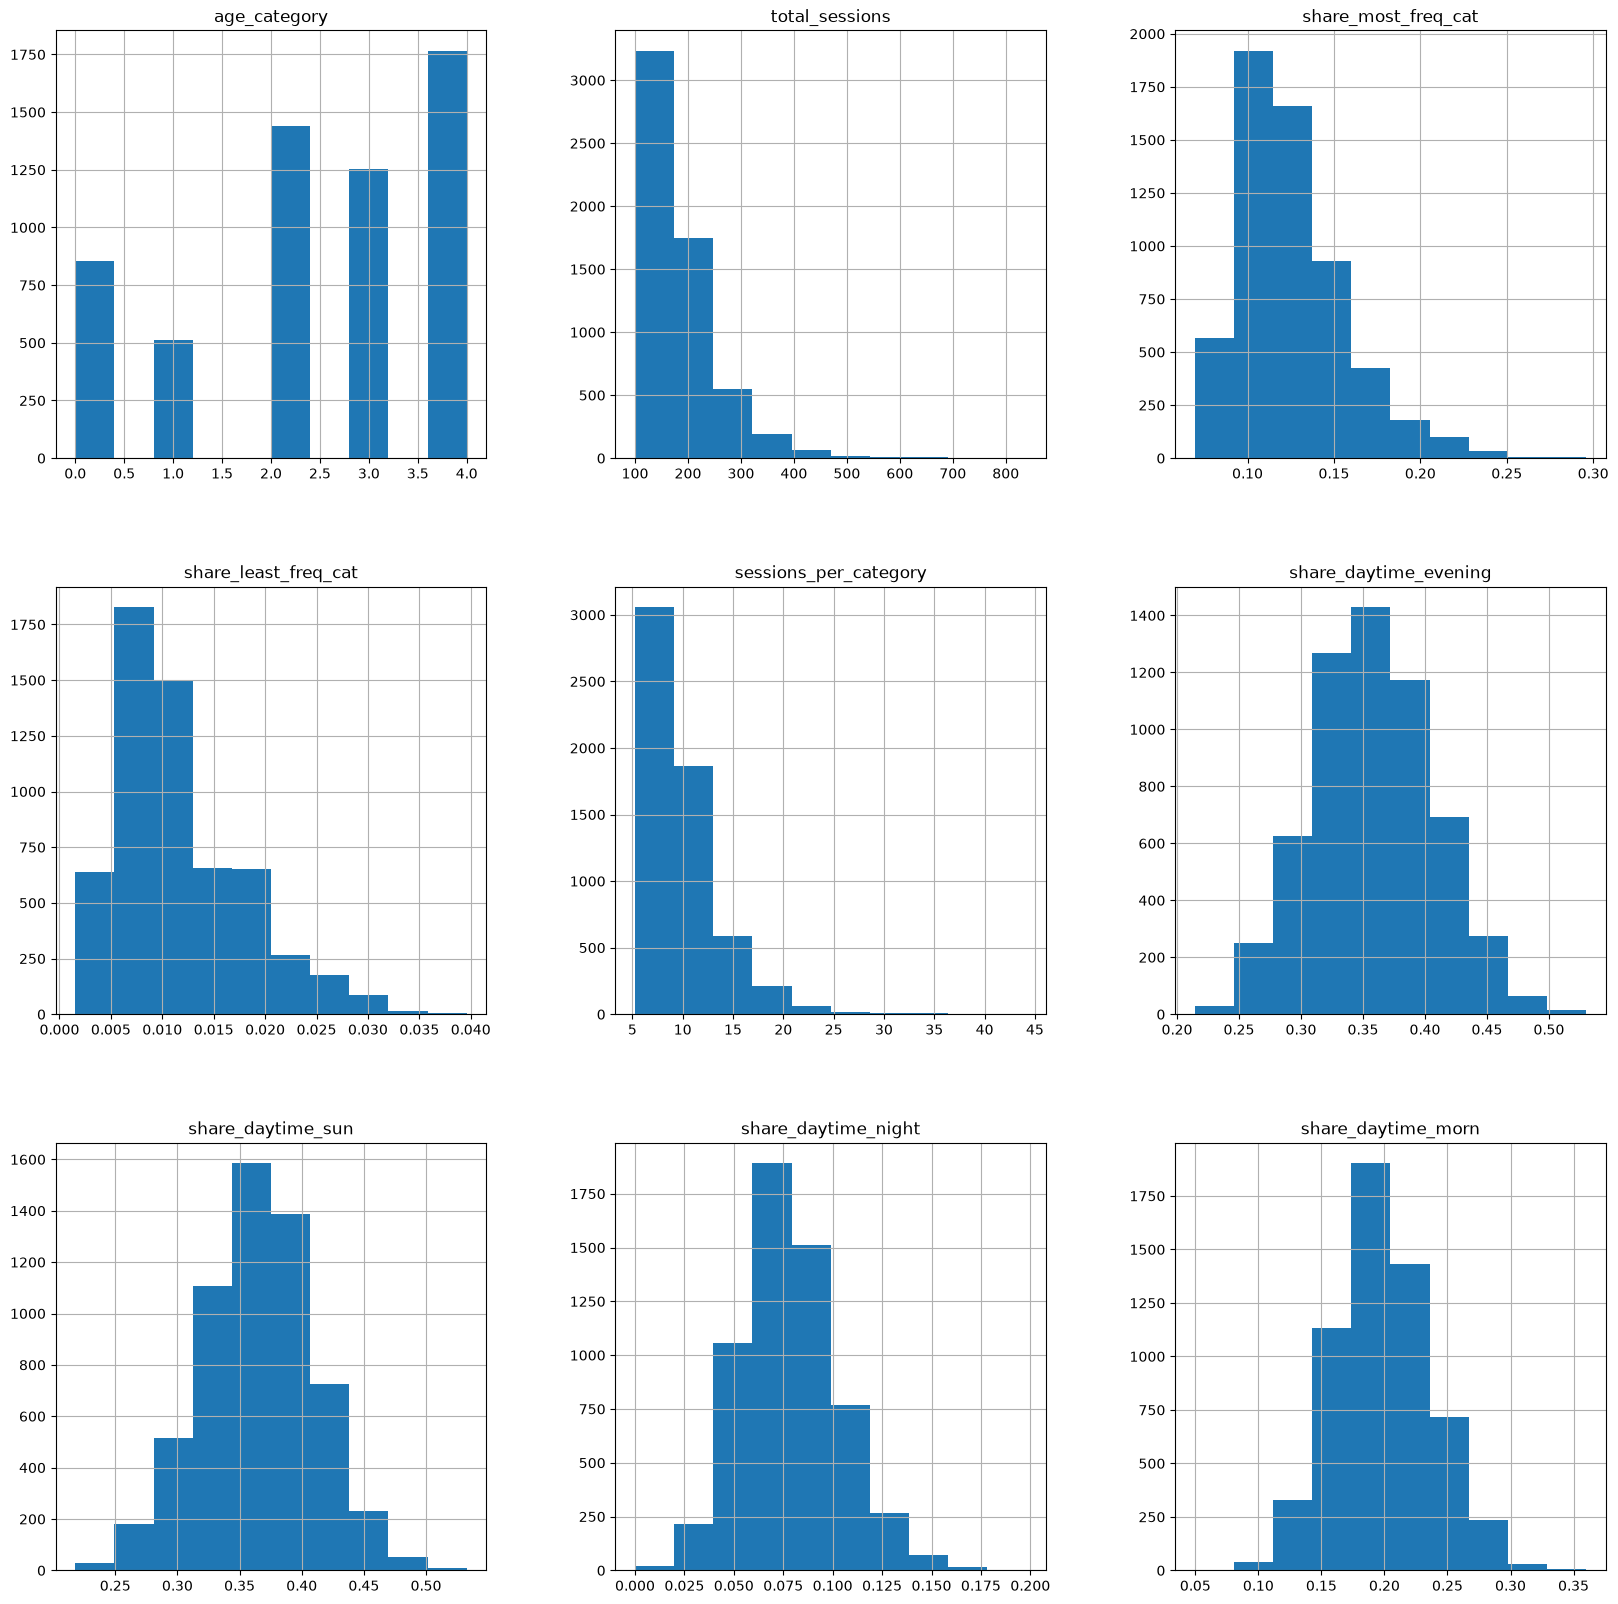

In [37]:
df_init.hist(figsize = (20,20))
plt.show()

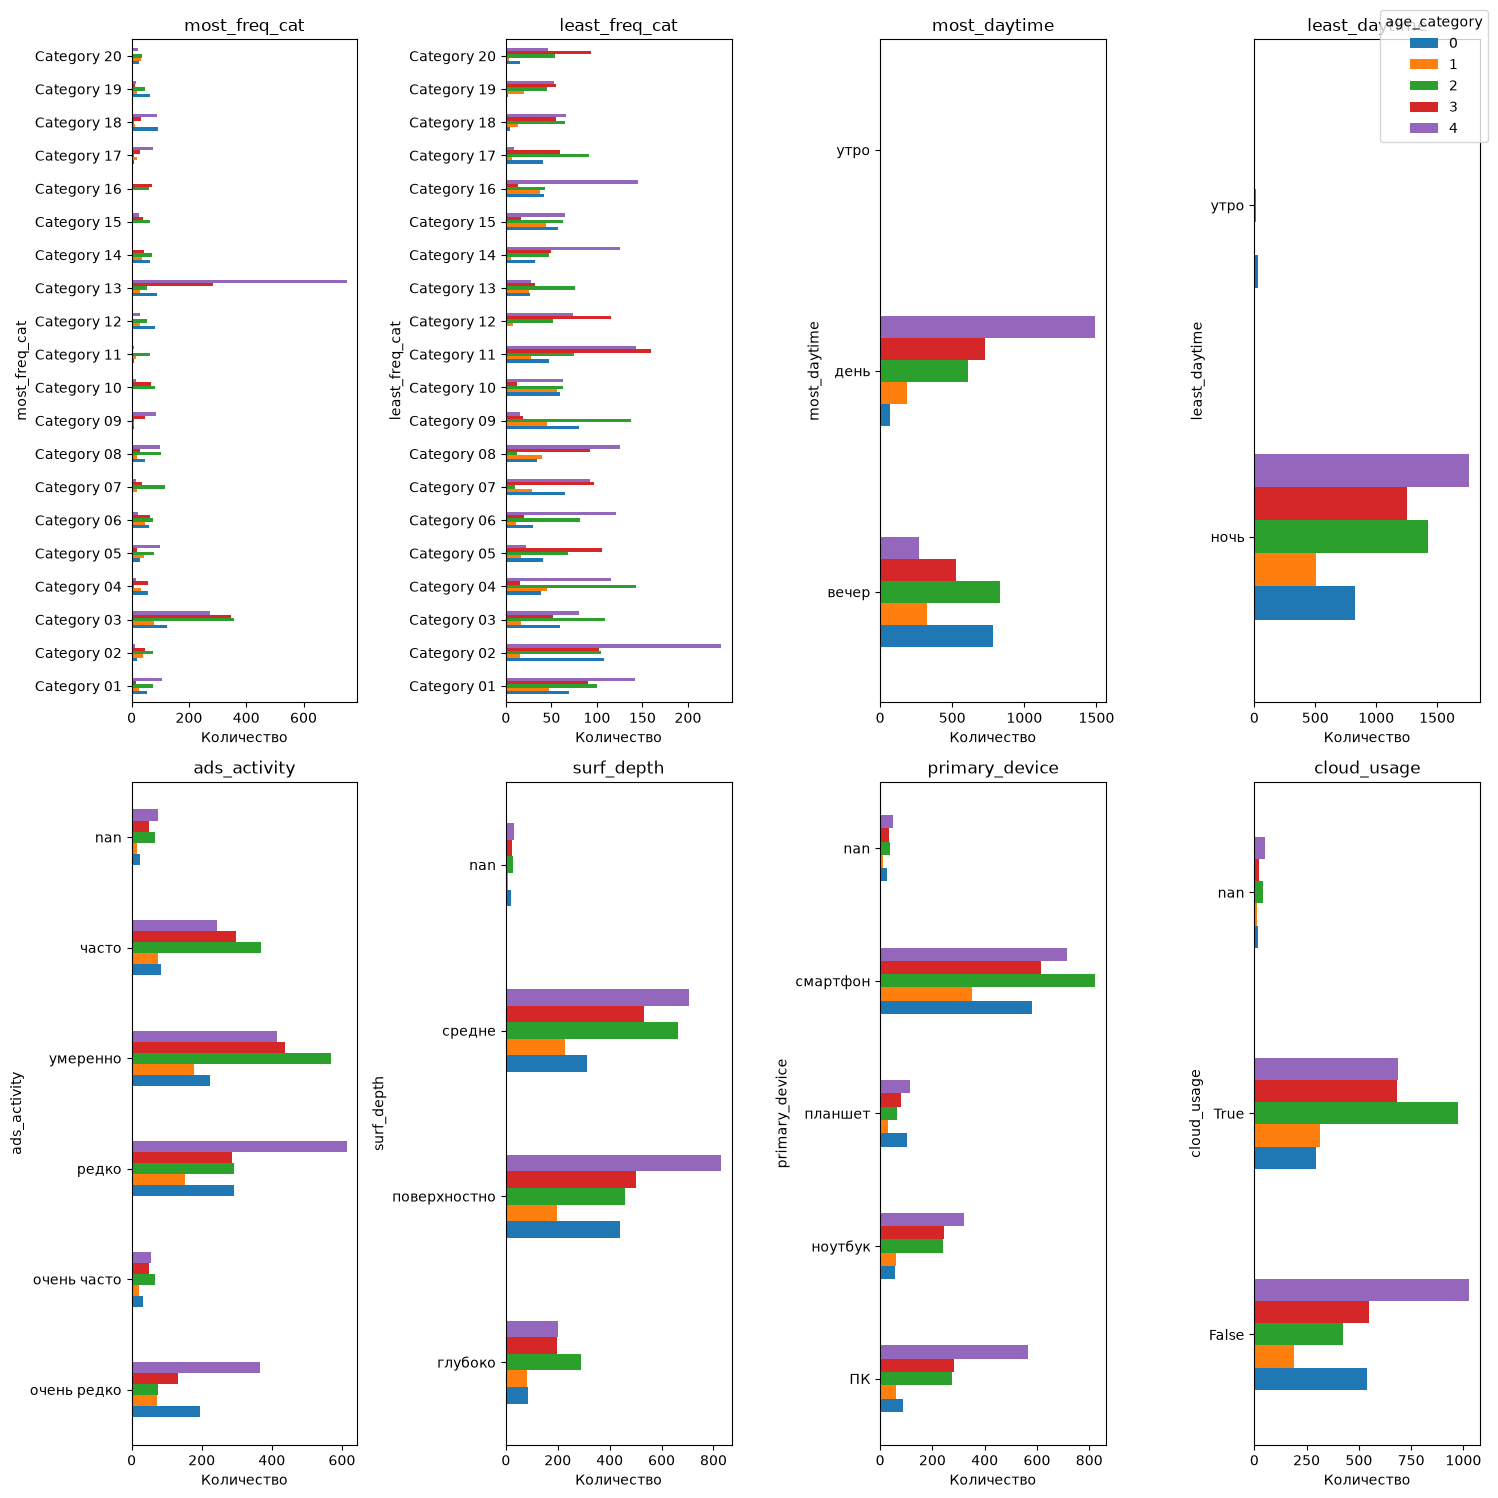

In [38]:
plot_cat_vs_target(df_init, 'age_category', exclude_cols=['user_id'], ncols=4)

In [39]:
df_init[df_init['least_daytime'] == 'утро'].shape[0]

52

**Выводы**

- Выбросов среди числовых нет, однако, имеется скошенность вправо распределений по части числовых признаков. Для улучшения работы модели будет разумно применить корень к числовым признакам: 'total_sessions', 'share_most_freq_cat', 'share_least_freq_cat', 'sessions_per_category'.
- Среди категориальных признаков заметны сильные разбросы по целевой переменной для разных категорий, что хорошо, т.к. целевая переменная различима по ним. В том числе доминирование одной категории над другими. Например, `Category_13` является важной для пользователей 56+. У `most_daytime`, `least_daytime` есть редкая категория значений - утро. Для `least_daytime` количество записей 52, что около 1 % процента от всех записей. Можно считать его почти константой, а значит этот признак можно удалять.

In [40]:
df_init = df_init.drop(columns = ['least_daytime'])

<a id='p2c'></a>

---

### Корреляция

[К Содержимому проекта](#contents)

Для оценки корреляции между признаками и особенно коллинеарности необходимо провести часть предобработки. Для этого создадим временный датафрейм, в котором проведем упрощенную предобработку для общей оценки связей между признаками.

**Замечание:** Часть признаков будет заполнена медианой для простоты. Временный датафрейм будет удален после проверки на корреляцию, данные из него не будут использованы для построение модели машинного обучения. Подобная замена проводится только в целях EDA. Мне кажется, что использование медианы в данном контексте не стоит считать утечкой.

In [41]:
def plot_heatmap(data,title,xlabel,ylabel,figsize = (4,4)):
    plt.figure(figsize=figsize)
    fig = sns.heatmap(data,
                      annot=True, # Отображаем численные значения в ячейках карты
                      fmt='.2f', # Форматируем значения корреляции: два знака после точки
                      cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                      linewidths=0.5, # Форматируем линию между ячейками карты
                      cbar=False # Отключаем цветовую шкалу
                      ,annot_kws={'size': 10}
                      ,mask = np.triu(np.ones_like(data, dtype=bool))
                     )
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    fig.tick_params(axis='both', labelsize=12)    
    
    plt.show()

In [42]:
df = df_init.drop(columns=['user_id']).copy()

for col in ['ads_activity', 'surf_depth', 'primary_device']:
    df[col] = df[col].fillna('неизвестно')

medi = df['cloud_usage'].median()
df['cloud_usage'] = df['cloud_usage'].fillna(medi)
df['cloud_usage'] = pd.to_numeric(df['cloud_usage'], errors='raise', downcast='integer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age_category           5826 non-null   int64  
 1   total_sessions         5826 non-null   int64  
 2   most_freq_cat          5826 non-null   str    
 3   least_freq_cat         5826 non-null   str    
 4   share_most_freq_cat    5826 non-null   float64
 5   share_least_freq_cat   5826 non-null   float64
 6   sessions_per_category  5826 non-null   float64
 7   share_daytime_evening  5826 non-null   float64
 8   share_daytime_sun      5826 non-null   float64
 9   share_daytime_night    5826 non-null   float64
 10  share_daytime_morn     5826 non-null   float64
 11  most_daytime           5826 non-null   str    
 12  ads_activity           5826 non-null   str    
 13  surf_depth             5826 non-null   str    
 14  primary_device         5826 non-null   str    
 15  cloud_usage    

In [43]:
cols = df.select_dtypes(include=["float64","int64"]).columns.tolist()
cols = [col for col in cols if col not in ['age_category']]
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
not_cols = [col for col in list(df.columns) if col not in cat_cols]

correlation_matrix_phik = df.phik_matrix(interval_cols = cols)
correlation_matrix_pearson = df[not_cols].corr(method='pearson')
correlation_matrix_spearman = df[not_cols].corr(method='spearman')

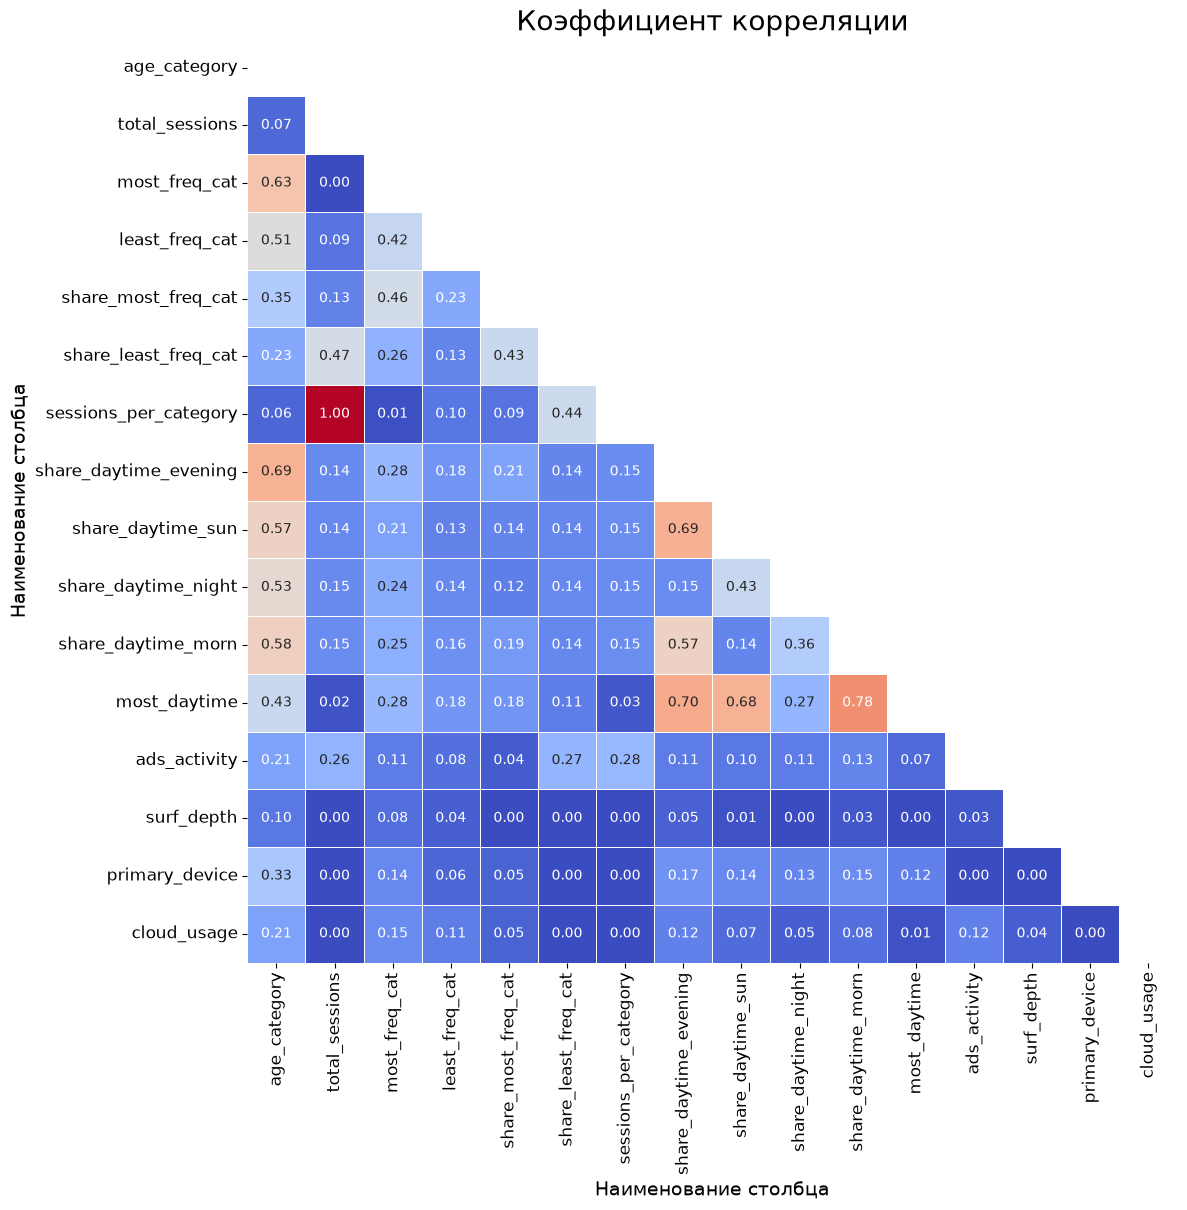

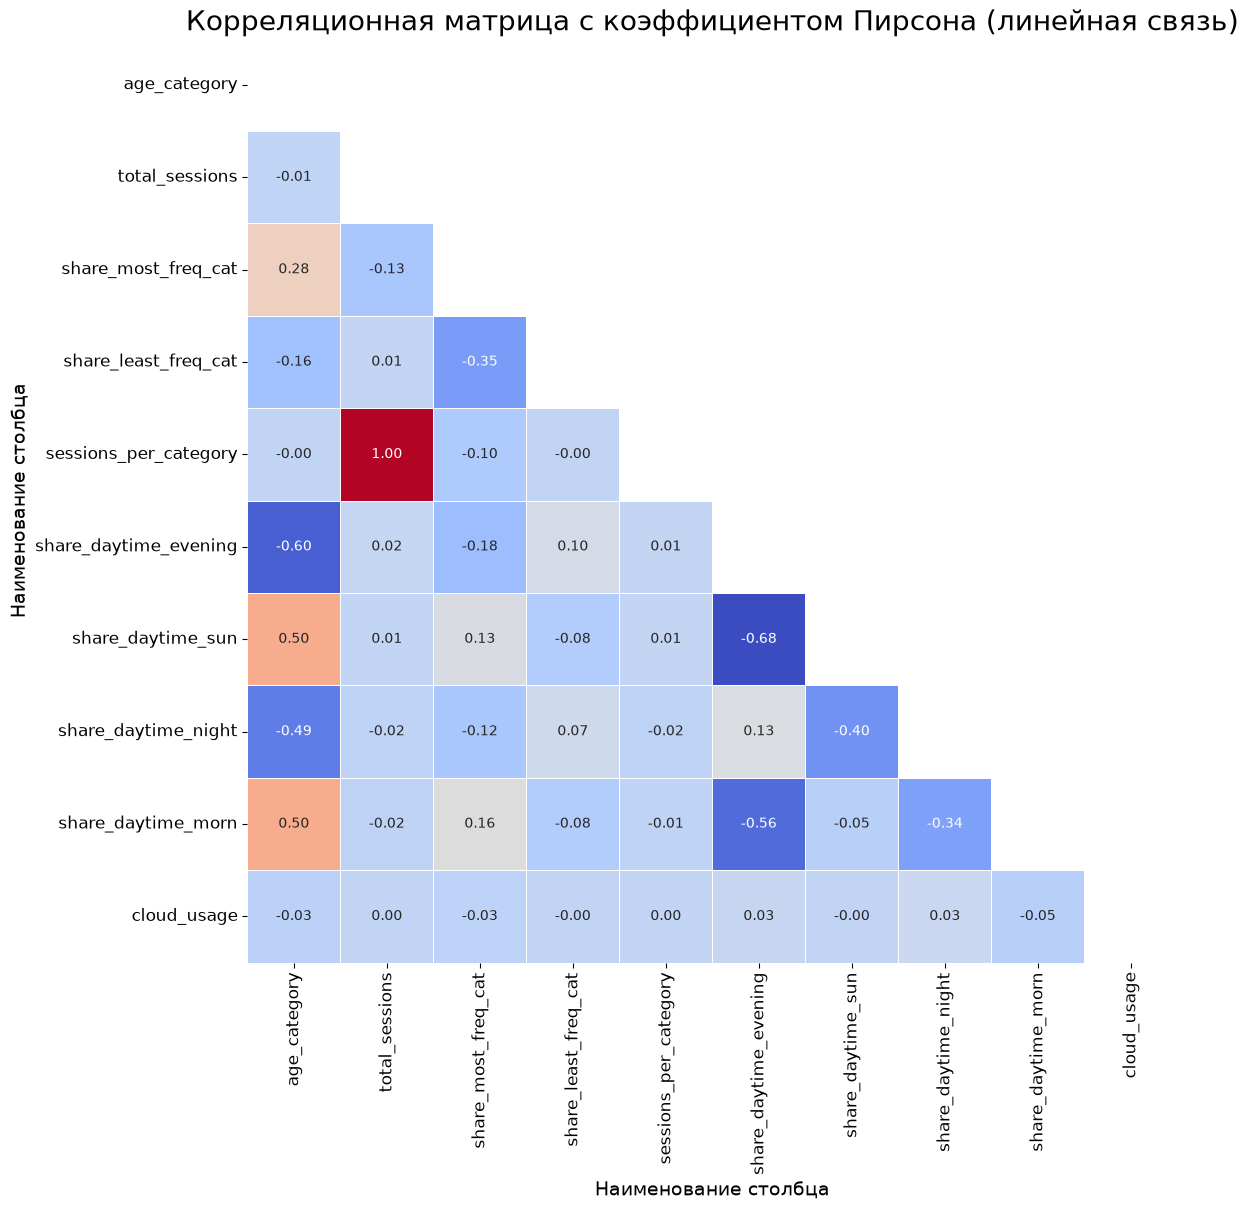

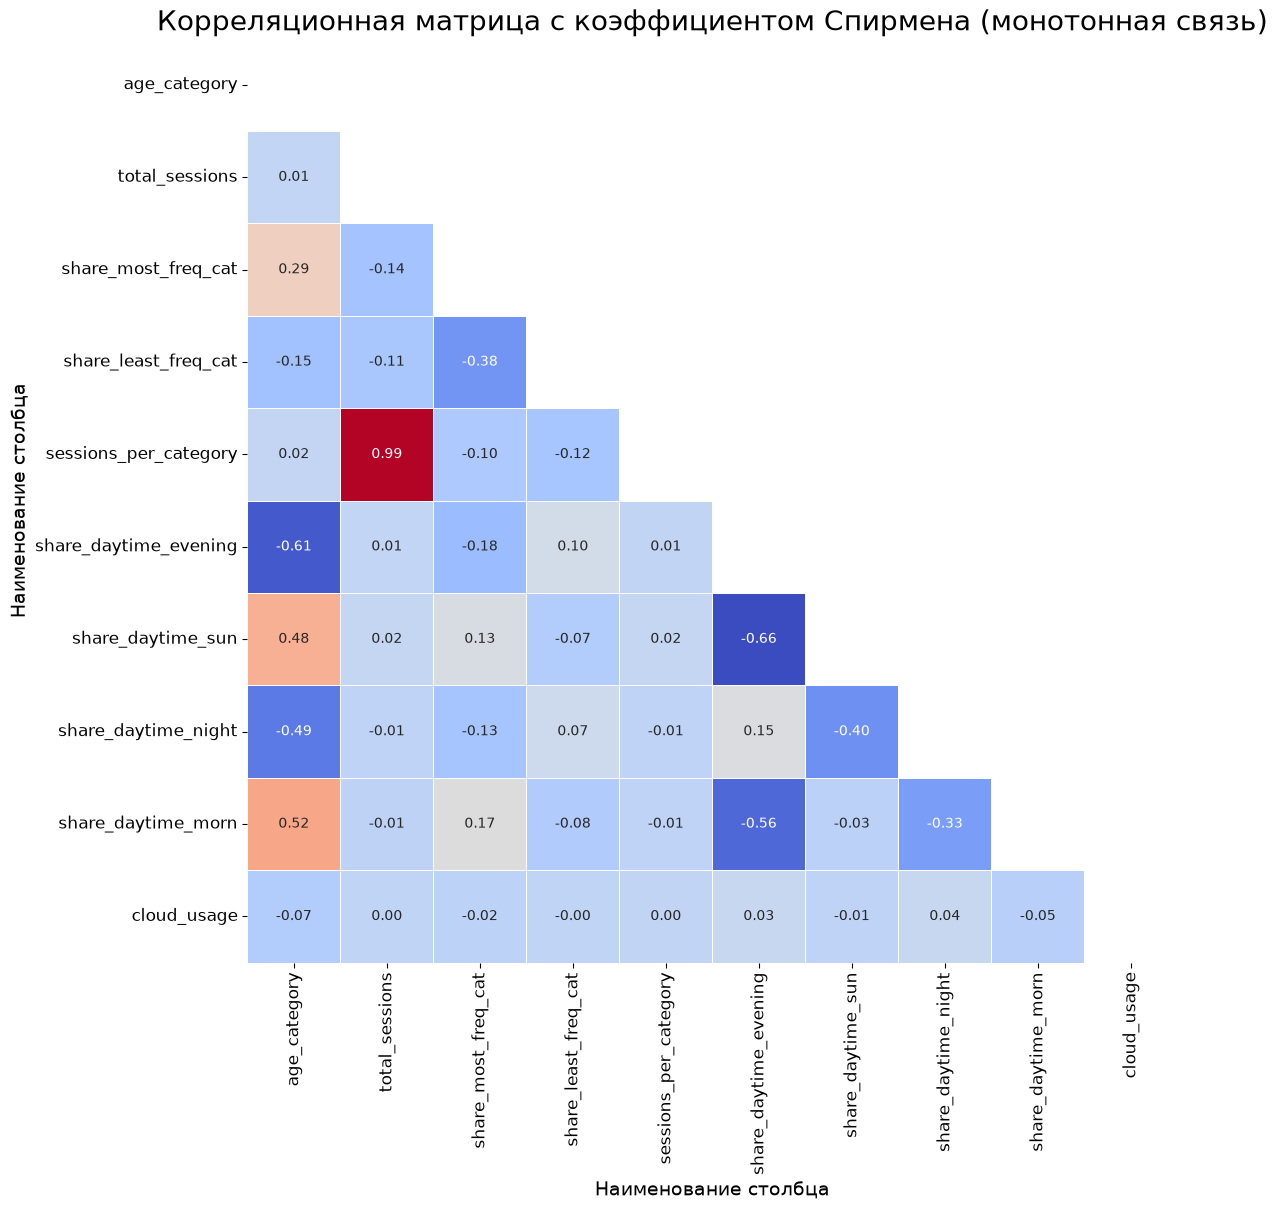

In [44]:
plot_heatmap(correlation_matrix_phik,'Коэффициент корреляции','Наименование столбца','Наименование столбца',figsize = (12,12))
plot_heatmap(correlation_matrix_pearson,'Корреляционная матрица с коэффициентом Пирсона (линейная связь)','Наименование столбца','Наименование столбца',figsize = (12,12))
plot_heatmap(correlation_matrix_spearman,'Корреляционная матрица с коэффициентом Спирмена (монотонная связь)','Наименование столбца','Наименование столбца',figsize = (12,12))

Заметна сильная корреляции между `sessions_per_category` и `total_sessions`, связь почти линейная. Из пары удалим `sessions_per_category`, т.к. он является производным от `total_sessions`.

Кроме того, проверим на мультиколлинеарность. Для проверки на мультиколлинеарность используется коэффициент variance_inflation_factor (VIF). В рамках данного коэффициент для каждого признака строится регрессия этого признака на все остальные признаки. Если остальные признаки хорошо объясняют его значение, VIF получается большим - это признак мультиколлинеарности.

У VIF есть формула: $ \text{VIF} = \frac{1}{1-R^2_i}$. Здесь $R^2_i$ - коэффициент детерминации при регрессии i-го признака на все остальные признаки.

Традиционно, показатель значения показателя оценивают примерно так: 
- VIF $\approx$ 1 - мультиколлинеарности практически нет
- VIF $\in(1,5)$ допустимый уровень
- VIF $\in[5,10]$ заметная мультиколлинеарность
- VIF > 10 сильная мультиколлинеарность

In [45]:
Xpr = df.drop(columns=['age_category'] + cat_cols).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
8,share_daytime_morn,inf
5,share_daytime_evening,inf
7,share_daytime_night,inf
6,share_daytime_sun,inf
1,total_sessions,123.789646
4,sessions_per_category,122.959670
2,share_most_freq_cat,1.311810
3,share_least_freq_cat,1.148082
9,cloud_usage,1.004961
0,const,0.000000


Ой, не подумал, что в сумме доли `share_daytime` дают единицу, а значит описывают свободный член линейной регрессии. Уберем одну из долей, а также `sessions_per_category` ввиду сильной связи с `total_sessions`:

In [46]:
Xpr = df.drop(columns=['age_category', 'sessions_per_category', 'share_daytime_morn'] + cat_cols).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,feature,VIF
0,const,555.467272
5,share_daytime_sun,2.289282
4,share_daytime_evening,1.996995
6,share_daytime_night,1.266504
2,share_most_freq_cat,1.205300
3,share_least_freq_cat,1.148023
1,total_sessions,1.018967
7,cloud_usage,1.003896


После исключения `sessions_per_category`, `share_daytime_morn` падает до приемлимых величин. Исключаем `share_daytime_morn`, исходя из связи с другими признаками.

<a id='p2d'></a>

---

### Выводы по EDA

[К Содержимому проекта](#contents)

Исследовательский анализ показал, что исходные данные содержат достаточно информации для построения модели определения возрастной категории пользователя. После удаления явных дубликатов и объединения нескольких источников данных по `user_id` получен итоговый датафрейм на 5826 пользователей и 18 признаков, где одна строка соответствует одному пользователю.

Анализ целевой переменной `age_category` показал наличие дисбаланса классов. Наиболее многочисленной является группа **56+**, а наименее многочисленной - **18-25 лет**. При этом несовершеннолетние пользователи не являются самым редким классом. Для оценки качества моделей поэтому будет использоваться `F1 macro`, а также `Precision macro` и `Recall macro`, чтобы все возрастные категории имели одинаковый вес.

Для таблицы `ds_s13_visits` выполнена агрегация на уровень пользователя. Созданы признаки общей активности (`total_sessions`), наиболее и наименее популярных категорий (`most_freq_cat`, `least_freq_cat` и их доли), распределения активности по времени суток (`share_daytime`), а также наиболее и наименее активное время суток `most_daytime`. Анализ показал, что некоторые дополнительные признаки неинформативны: `active_days` практически всегда равен 14 и поэтому был исключён, `least_daytime` практически всегда ночь, поэтому он тоже был исключен.

Категориальные признаки будут обрабатываться с помощью OneHotEncoder. Пропуски в категориальных признаках, возникшие после объединения таблиц, будут выделены в отдельную категорию неизвестно. Пропуски в `cloud_usage` будут обработаны в рамках пайплайна предобработки и заполнен медианой. Технический идентификатор `user_id` в модель не передаётся.

Анализ признаков показал заметные различия в поведении пользователей разных возрастных групп, особенно по категориям посещаемых сайтов. Для отдельных категорий наблюдается выраженное доминирование среди определённых возрастных групп, что подтверждает потенциальную информативность признаков из `visits`.

Выраженных выбросов среди числовых признаков не обнаружено, однако часть распределений имеет правостороннюю асимметрию. Для таких признаков будет рассмотрено нелинейное преобразование перед обучением линейных моделей.

При анализе мультиколлинеарности обнаружена сильная зависимость между `total_sessions` и `sessions_per_category`, поэтому `sessions_per_category` исключён как производный и избыточный признак. Также признаки `share_daytime` в сумме дают единицу, поэтому один из них (`share_daytime_morn`) был удалён для устранения совершенной линейной зависимости.

---

<a id='p3'></a>

## Предобработка данных

[К Содержимому проекта](#contents)

Разделим выборки и подготовим pipeline по предобработке.

In [47]:
df = df_init.copy()
X = df.drop(columns=['age_category']).copy()
y = df['age_category'].copy()
X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=random_state)

print(color.BOLD + color.RED + '\nРазмеры выборок:'  + color.END)
print(color.BLUE + '\n X Train-Val выборка: '  + color.END + str(X_train_val.shape))
print(color.BLUE + '\n y Train-Val выборка: '  + color.END + str(y_train_val.shape))
print(color.GREEN + '\n X Test выборка: '  + color.END + str(X_test.shape))
print(color.GREEN + '\n y Test выборка: '  + color.END + str(y_test.shape))


Размеры выборок:

 X Train-Val выборка: (4660, 16)

 y Train-Val выборка: (4660,)

 X Test выборка: (1166, 16)

 y Test выборка: (1166,)


In [48]:
#Функция для обработки колонок
def features_checker(X_train_val):
    X = X_train_val.copy()
    X = X.drop(['user_id', 'sessions_per_category', 'share_daytime_morn'], axis=1)
    
    cols = ['total_sessions', 'share_most_freq_cat', 'share_least_freq_cat']
    for col in cols:
        X[col] = np.sqrt(X[col])
    X['cloud_usage'] = pd.to_numeric(X['cloud_usage'], errors='raise')
    return X

In [49]:
# Pipeline для категориальных признаков
ohe_list = features_checker(X_train_val).select_dtypes(include=["object", "string", "category"]).columns.tolist()

ohe_pipeline = Pipeline([ 
    ('imputer_ohe', SimpleImputer(strategy='constant', fill_value='неизвестно')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Pipeline для категориальных признаков с большим количеством категорий
TEncode_list = []

# Pipeline для бинарных категориальных признаков
binary_list = ['cloud_usage']

binary_pipeline = Pipeline([
    ('imputer_binary_cat', SimpleImputer( strategy='median'))
])

# Pipeline для числовых признаков с масштабированием
num_list = features_checker(X_train_val).select_dtypes(include=["float64"]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer_num', SimpleImputer( strategy='median')),
    ('Standard', StandardScaler())
])

# ColumnTransformer для всех колонок
num_cat_preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', ohe_pipeline, ohe_list),
        ('binary', binary_pipeline, binary_list),
        ('num_standard', num_pipeline, num_list)
    ])

# Pipeline для базовой предобработки без создания новых признаков
Base_preprocessor_pipeline = Pipeline([
    ('features_checker', FunctionTransformer(features_checker, validate=False)),
    ('num_cat_preprocessor',num_cat_preprocessor)
])

In [50]:
# работает только для pipeline с последовательностью шагов - обработка колонок в начале, ohe, TEncode, binary, num_standard
def get_feature_name(preprocessor_pipeline, X_train_val, y_train_val, ohe_list, TEncode_list, binary_list, num_list):
    preprocessor_pipeline.fit(X_train_val,y_train_val) # Обязательно, иначе признаки не существуют при обращении к ним
    ColTran = preprocessor_pipeline.named_steps['num_cat_preprocessor']
    ohe = ColTran.named_transformers_['cat_ohe'].named_steps['ohe']
    return list(ohe.get_feature_names_out(ohe_list)) + TEncode_list + binary_list + num_list

---

<a id='p4a'></a>

## Обучение и оценка базовой модели

---

### `DummyClassifier`

В качестве базового, будем использовать DummyClassifier.

[К Содержимому проекта](#contents)

In [51]:
# Функция для вычисленя метрик без кросс-валидации
def Metrics_Calc_Simple_Est(model, X, y_true, need_fit = False, model_name = 'Unknown', fold_name = 'Unknown'):
    if need_fit:
        model.fit(X, y_true)
    
    y_pred = model.predict(X)
    
    return {
        'model_name': model_name,
        'fold_name': fold_name,
        'F1_macro': f1_score(y_true, y_pred, average = 'macro'),
        'Precision_macro': precision_score(y_true, y_pred, average = 'macro'),
        'Recall_macro': recall_score(y_true, y_pred, average = 'macro'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_weighted': f1_score(y_true, y_pred, average = 'weighted'),
        'Precision_weighted': precision_score(y_true, y_pred, average = 'weighted'),
        'Recall_weighted': recall_score(y_true, y_pred, average = 'weighted')
    }

# Подпрограмма для усреденения метрик и вывода в виде датафрейма
def Metrics_Calc_Cross_Validate(cv_results, scoring, model_name = 'Unknown', name_folds = ['train','valid']):
    metrics_list = []
    cv_folds_name = ['train','test']
    df = pd.DataFrame(cv_results)
    df = df.drop('estimator', axis = 1)
    mean_series = df.mean().round(4)
    std_series = df.std().round(4)
    for i in range(0,2,1):
        metrics_dict = {'model_name': model_name, 'fold_name' : name_folds[i]}
        for score in scoring:
            if score == 'neg_log_loss':
                sign = -1
            else:
                sign = 1
            
            if score == 'average_precision':
                scorename = 'pr_auc'
            else:
                scorename = score
            
            metrics_dict[scorename] = f'{sign * mean_series[f"{cv_folds_name[i]}_{score}"]} ± {sign * std_series[f"{cv_folds_name[i]}_{score}"]}'
        
        metrics_list = metrics_list + [metrics_dict]

    return metrics_list

In [52]:
DummyModel = DummyClassifier()
DummyModel.fit(X_train_val, y_train_val)
metrics_df = pd.DataFrame([
    Metrics_Calc_Simple_Est(DummyModel, X_train_val, y_train_val, need_fit = False, model_name = 'Dummy_Model', fold_name = 'train_val')
])
metrics_df = metrics_df.round(4)

display(metrics_df)

C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model_name,fold_name,F1_macro,Precision_macro,Recall_macro,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
0,Dummy_Model,train_val,0.0931,0.0606,0.2,0.3032,0.1411,0.0919,0.3032


<a id='p4b'></a>

---

### `LogisticRegression`

[К Содержимому проекта](#contents)

Одна из первых моделей для анализа `LogisticRegression`. Посмотрим на ее результаты без дополнительной чистки признаков.

In [53]:
# Для платформы из-за разности библиотек
#LRModel = LogisticRegression(random_state=random_state, max_iter = 1000, class_weight="balanced", multi_class="multinomial", solver="lbfgs", penalty="l2")
# Для Git
LRModel = LogisticRegression(random_state=random_state, max_iter = 1000, class_weight="balanced", solver="lbfgs")

LogRegPipe = Pipeline(steps=[
    ('preprocessing', Base_preprocessor_pipeline),
    ('model', LRModel)
])

scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
Stratkfold5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

LR_CV_results = cross_validate(
    estimator=LogRegPipe,        # модель или pipeline
    X=X_train_val,               # признаки
    y=y_train_val,               # целевая переменная
    scoring=scoring,             # список метрик
    cv=Stratkfold5,              # стратегия разбиения
    return_train_score = True,   # расчёт качества на трейне
    return_estimator = True,     # сохранение обученных экземпляров модели
    n_jobs=-1                    # использовать все ядра, при -1. Если int, то количество
)

In [54]:
pd.DataFrame(Metrics_Calc_Cross_Validate(LR_CV_results, scoring, model_name = 'LogisticRegression', name_folds = ['train','valid'])).sort_values(by = 'f1_macro',ascending=False).head(10)

,model_name,fold_name,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
0,LogisticRegression,train,0.6426 ± 0.0054,0.6391 ± 0.0047,0.6568 ± 0.0051,0.6712 ± 0.0049,0.6765 ± 0.0045,0.6885 ± 0.0036,0.6712 ± 0.0049
1,LogisticRegression,valid,0.6145 ± 0.0183,0.6138 ± 0.0174,0.6259 ± 0.0195,0.6466 ± 0.0158,0.6529 ± 0.0156,0.666 ± 0.0151,0.6466 ± 0.0158


<a id='p4c'></a>

---

### `SVC` с линейным ядром

[К Содержимому проекта](#contents)

Посмотрим на результаты `SVC` с линейным ядром без дополнительной чистки признаков. Сопоставим обе версии *One Vs Rest* и *One Vs One*. В первом случае строится 5 моделей для одной итерации кросс-валидации, во втором случае 10 моделей, что не критично.

In [55]:
SVCLinModel = SVC(kernel='linear', random_state=random_state, max_iter = 1000, probability=True)

SVCLinPipe = Pipeline(steps=[
    ('preprocessing', Base_preprocessor_pipeline),
    ('model', SVCLinModel)
])

OVR_SVC_Lin = OneVsRestClassifier(SVCLinPipe, n_jobs = -1)

scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

SVCLin_CV_results = cross_validate(
    estimator=OVR_SVC_Lin,       # модель или pipeline
    X=X_train_val,               # признаки
    y=y_train_val,               # целевая переменная
    scoring=scoring,             # список метрик
    cv=Stratkfold5,              # стратегия разбиения
    return_train_score = True,   # расчёт качества на трейне
    return_estimator = True,     # сохранение обученных экземпляров модели
    n_jobs=-1                    # использовать все ядра, при -1. Если int, то количество
)

In [56]:
SVCLinModel = SVC(kernel='linear', random_state=random_state, max_iter = 1000, probability=True)
OVO_SVC_Lin_model = OneVsOneClassifier(SVCLinModel, n_jobs = -1)

OVO_SVC_Lin = Pipeline(steps=[
    ('preprocessing', Base_preprocessor_pipeline),
    ('model', OVO_SVC_Lin_model)
])

scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

SVCLin_CV_OVO = cross_validate(
    estimator=OVO_SVC_Lin,       # модель или pipeline
    X=X_train_val,               # признаки
    y=y_train_val,               # целевая переменная
    scoring=scoring,             # список метрик
    cv=Stratkfold5,              # стратегия разбиения
    return_train_score = True,   # расчёт качества на трейне
    return_estimator = True,     # сохранение обученных экземпляров модели
    n_jobs=-1                    # использовать все ядра, при -1. Если int, то количество
)

In [57]:
Met_List = Metrics_Calc_Cross_Validate(SVCLin_CV_results, scoring, model_name = 'SVC_Linear_OvR', name_folds = ['train','valid'])
Met_List = Met_List + Metrics_Calc_Cross_Validate(SVCLin_CV_OVO, scoring, model_name = 'SVC_Linear_OvO', name_folds = ['train','valid'])
pd.DataFrame(Met_List).sort_values(by = 'f1_macro',ascending=False).head(10)

,model_name,fold_name,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
2,SVC_Linear_OvO,train,0.6259 ± 0.0089,0.6414 ± 0.009,0.6226 ± 0.0084,0.6748 ± 0.0075,0.6666 ± 0.0081,0.6651 ± 0.0082,0.6748 ± 0.0075
3,SVC_Linear_OvO,valid,0.5732 ± 0.0107,0.5816 ± 0.0109,0.5721 ± 0.0108,0.6288 ± 0.0055,0.6206 ± 0.0069,0.6169 ± 0.0072,0.6288 ± 0.0055
0,SVC_Linear_OvR,train,0.4706 ± 0.0164,0.4907 ± 0.0129,0.4701 ± 0.0163,0.524 ± 0.0127,0.5163 ± 0.0138,0.5213 ± 0.0131,0.524 ± 0.0127
1,SVC_Linear_OvR,valid,0.453 ± 0.0338,0.4697 ± 0.0306,0.4533 ± 0.0341,0.5043 ± 0.0249,0.4976 ± 0.0233,0.5024 ± 0.0206,0.5043 ± 0.0249


<a id='p4d'></a>

---

### `SVC` с нелинейным ядром

[К Содержимому проекта](#contents)

Посмотрим на результаты `SVC` с нелинейным ядром без дополнительной чистки признаков. Сопоставим обе версии *One Vs Rest* и *One Vs One*.

In [58]:
SVCNonLin = SVC(kernel='rbf', gamma='auto', random_state=random_state, max_iter = 1000, probability=True)

SVCNonLinPipe = Pipeline(steps=[
    ('preprocessing', Base_preprocessor_pipeline),
    ('model', SVCNonLin)
])

OVR_SVC_NonLin = OneVsRestClassifier(SVCNonLinPipe, n_jobs = -1)

scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

SVCNonLin_CV_results = cross_validate(
    estimator=OVR_SVC_NonLin,    # модель или pipeline
    X=X_train_val,               # признаки
    y=y_train_val,               # целевая переменная
    scoring=scoring,             # список метрик
    cv=Stratkfold5,              # стратегия разбиения
    return_train_score = True,   # расчёт качества на трейне
    return_estimator = True,     # сохранение обученных экземпляров модели
    n_jobs=-1                    # использовать все ядра, при -1. Если int, то количество
)

In [59]:
SVCNonLin = SVC(kernel='rbf', gamma='auto', random_state=random_state, max_iter = 1000, probability=True)
OVO_SVC_NonLin_pipe = OneVsOneClassifier(SVCNonLin, n_jobs = -1)

OVO_SVC_NonLin = Pipeline(steps=[
    ('preprocessing', Base_preprocessor_pipeline),
    ('model', OVO_SVC_NonLin_pipe)
])

scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

SVCNonLin_CV_OVO = cross_validate(
    estimator=OVO_SVC_NonLin,       # модель или pipeline
    X=X_train_val,               # признаки
    y=y_train_val,               # целевая переменная
    scoring=scoring,             # список метрик
    cv=Stratkfold5,              # стратегия разбиения
    return_train_score = True,   # расчёт качества на трейне
    return_estimator = True,     # сохранение обученных экземпляров модели
    n_jobs=-1                    # использовать все ядра, при -1. Если int, то количество
)

In [60]:
Met_List = Metrics_Calc_Cross_Validate(SVCNonLin_CV_results, scoring, model_name = 'SVC_Non_Linear_OvR', name_folds = ['train','valid'])
Met_List = Met_List + Metrics_Calc_Cross_Validate(SVCNonLin_CV_OVO, scoring, model_name = 'SVC_Non_Linear_OvO', name_folds = ['train','valid'])
pd.DataFrame(Met_List).sort_values(by = 'f1_macro',ascending=False).head(10)

,model_name,fold_name,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
2,SVC_Non_Linear_OvO,train,0.5633 ± 0.0072,0.6829 ± 0.0375,0.5834 ± 0.0054,0.6722 ± 0.0039,0.6424 ± 0.0051,0.6809 ± 0.017,0.6722 ± 0.0039
3,SVC_Non_Linear_OvO,valid,0.5377 ± 0.0153,0.6445 ± 0.0776,0.5585 ± 0.0152,0.6451 ± 0.0143,0.6152 ± 0.0137,0.6488 ± 0.0417,0.6451 ± 0.0143
0,SVC_Non_Linear_OvR,train,0.5295 ± 0.0051,0.6599 ± 0.0082,0.5632 ± 0.004,0.6498 ± 0.004,0.599 ± 0.0057,0.6621 ± 0.0055,0.6498 ± 0.004
1,SVC_Non_Linear_OvR,valid,0.4904 ± 0.0155,0.5809 ± 0.0643,0.5319 ± 0.009,0.618 ± 0.0076,0.5607 ± 0.0115,0.6047 ± 0.0356,0.618 ± 0.0076


<a id='p4e'></a>

---

### Выводы

[К Содержимому проекта](#contents)

В результате предварительных испытаний все модели превзошли `DummyClassifier` по всем метрикам. `One vs One` показывает лучшие результаты во всех случаях, поэтому далее не будем использовать `One vs Rest`, т.к. разница по времени почти не заметна

Однако, в настоящий момент они не могут быть рекомендованы к внедрению, т.к. установлен порог по `F1 macro` не менее 0.75 как на кросс-валидации обучающей выборки, так и на тестовой выборке. Лучшая модель `SVC_Linear_OvO` пока показывает по ключевой метрики около 0.61 на валидационной выборке. Для улучшения результатов следует:
- Провести отбор признаков с целью улучшения ключевых показателей.
- Подобрать гиперпараметры.

---

<a id='p5a'></a>

## Создание и отбор признаков

Для отбора признаков будем использовать два метода - метод обертки и метод через L1-регуляризацию. 

---

### Методы обертки

[К Содержимому проекта](#contents)

In [61]:
def wrapper_selection(method_name, estimator, X, y, feature_names, k=(1, 10), 
                      forward=True, rfe_k=None, scoring_metric = None, step = 2):
    start_time = time()
    if method_name == 'RFE':
        selector = RFE(estimator, n_features_to_select=rfe_k, step = step)
        selector.fit(X, y)
        selected_idx = selector.support_
    else:
        selector = SFS(estimator, k_features=k, forward=forward, scoring=scoring_metric, cv=None, n_jobs=-1)
        selector.fit(X, y)
        selected_idx = list(selector.k_feature_idx_)

    elapsed = time() - start_time
    selected_features = np.array(feature_names)[selected_idx]
    return selected_features, elapsed

In [62]:
# Для платформы из-за разности библиотек
#lr_estimator = LogisticRegression(random_state=random_state, max_iter = 1000, class_weight="balanced", multi_class="multinomial", solver="lbfgs", penalty="l2")
# Для Git

lr_estimator = LogisticRegression(random_state=random_state, max_iter = 1000, class_weight="balanced", solver="lbfgs")
X_processed = Base_preprocessor_pipeline.fit_transform(X_train_val,y_train_val)
feature_names = get_feature_name(Base_preprocessor_pipeline, X_train_val, y_train_val, ohe_list, TEncode_list, binary_list, num_list)

In [63]:
f_features, elapsed = wrapper_selection('RFE', lr_estimator, X_processed, y_train_val, feature_names, rfe_k=45, step = 2)
print(color.BOLD + color.RED + '\nRFE, время работы: '  + color.END + str(round(elapsed,2)) + ' c')
print(color.BOLD + color.RED + '\nВыбранные признаки:'  + color.END)
print(f_features)
print(color.BOLD + color.BLUE + '\nИсключенные признаки:'  + color.END)
print([col for col in feature_names if col not in set(f_features)])


RFE, время работы: 0.9 c

Выбранные признаки:
['most_freq_cat_Category 01' 'most_freq_cat_Category 02'
 'most_freq_cat_Category 04' 'most_freq_cat_Category 05'
 'most_freq_cat_Category 06' 'most_freq_cat_Category 07'
 'most_freq_cat_Category 08' 'most_freq_cat_Category 09'
 'most_freq_cat_Category 10' 'most_freq_cat_Category 11'
 'most_freq_cat_Category 12' 'most_freq_cat_Category 13'
 'most_freq_cat_Category 14' 'most_freq_cat_Category 15'
 'most_freq_cat_Category 16' 'most_freq_cat_Category 17'
 'most_freq_cat_Category 18' 'most_freq_cat_Category 19'
 'most_freq_cat_Category 20' 'least_freq_cat_Category 02'
 'least_freq_cat_Category 04' 'least_freq_cat_Category 05'
 'least_freq_cat_Category 06' 'least_freq_cat_Category 07'
 'least_freq_cat_Category 08' 'least_freq_cat_Category 09'
 'least_freq_cat_Category 10' 'least_freq_cat_Category 11'
 'least_freq_cat_Category 12' 'least_freq_cat_Category 14'
 'least_freq_cat_Category 15' 'least_freq_cat_Category 16'
 'least_freq_cat_Category 17

<a id='p5b'></a>

---

### Отбор через L1-регуляризацию

[К Содержимому проекта](#contents)

In [64]:
# Подпрограграмма для перебора параметров
def L1_search_feature(preprocessor, X_train_val, y_train_val, Stratkfold, scoring, param_dict, random_state = 42):
    
    model = LogisticRegression(random_state=random_state, max_iter = 1000, solver='saga', penalty='l1')
    hyper_model = Pipeline(steps=[
            ('preprocessing', preprocessor),
            ('model', model)
    ])
    
    param_grid = [param_dict]
    grid_search = GridSearchCV(
        estimator=hyper_model,
        param_grid=param_grid,
        scoring=scoring,   # словарь метрик
        cv=Stratkfold,     # стратегия кросс-валидации
        n_jobs=-1,         # параллелизация
        refit='f1_macro',  # метрика для выбора лучшей модели
        return_train_score=True,
        verbose=1          # для отслеживания прогресса
    )
    
    grid_search.fit(X_train_val, y_train_val)
    
    prdf = pd.DataFrame(grid_search.cv_results_)
    resdf = pd.DataFrame(index=prdf.index)
    
    for param in param_dict.keys():
        resdf[param] = prdf[f"param_{param}"]
    
    for score in scoring:
        if score == 'neg_log_loss':
            sign = -1
        else:
            sign = 1
        
        if score == 'average_precision':
            scorename = 'pr_auc'
        else:
            scorename = score
        
        resdf[scorename] = '0'
        for i in prdf.index:
            resdf.loc[i,scorename] = f'{sign * prdf.loc[i, f"mean_test_{score}"]:.4f} ± {sign * prdf.loc[i, f"std_test_{score}"]:.4f}'
    
    return grid_search, resdf

In [65]:
param_dict = {'model__C': [1e-3, 1e-2, 1e-1, 2.5e-1, 5e-1, 7.5e-1, 1, 2, 1e1, 5e1], 
              'model__class_weight': ['balanced']}
Stratkfold3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

In [66]:
grid_search, resdf = L1_search_feature(Base_preprocessor_pipeline, X_train_val, y_train_val, Stratkfold3, scoring, param_dict, random_state = random_state)
display(resdf.sort_values(by = 'f1_macro',ascending=False).head(10))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,model__C,model__class_weight,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
5,0.750,balanced,0.6133 ± 0.0246,0.6118 ± 0.0236,0.6240 ± 0.0252,0.6459 ± 0.0225,0.6520 ± 0.0223,0.6638 ± 0.0220,0.6459 ± 0.0225
6,1.000,balanced,0.6130 ± 0.0237,0.6113 ± 0.0228,0.6241 ± 0.0241,0.6455 ± 0.0217,0.6515 ± 0.0217,0.6635 ± 0.0215,0.6455 ± 0.0217
4,0.500,balanced,0.6118 ± 0.0243,0.6100 ± 0.0225,0.6229 ± 0.0246,0.6442 ± 0.0226,0.6499 ± 0.0220,0.6614 ± 0.0208,0.6442 ± 0.0226
3,0.250,balanced,0.6104 ± 0.0201,0.6086 ± 0.0183,0.6213 ± 0.0194,0.6438 ± 0.0202,0.6493 ± 0.0196,0.6608 ± 0.0177,0.6438 ± 0.0202
7,2.000,balanced,0.6101 ± 0.0206,0.6087 ± 0.0201,0.6209 ± 0.0207,0.6429 ± 0.0184,0.6489 ± 0.0187,0.6611 ± 0.0189,0.6429 ± 0.0184
8,10.000,balanced,0.6089 ± 0.0217,0.6079 ± 0.0214,0.6197 ± 0.0219,0.6418 ± 0.0188,0.6479 ± 0.0191,0.6603 ± 0.0195,0.6418 ± 0.0188
9,50.000,balanced,0.6082 ± 0.0220,0.6072 ± 0.0217,0.6189 ± 0.0224,0.6412 ± 0.0188,0.6473 ± 0.0192,0.6598 ± 0.0197,0.6412 ± 0.0188
2,0.100,balanced,0.5812 ± 0.0178,0.5795 ± 0.0160,0.5934 ± 0.0170,0.6155 ± 0.0187,0.6198 ± 0.0183,0.6316 ± 0.0163,0.6155 ± 0.0187
1,0.010,balanced,0.4563 ± 0.0080,0.4586 ± 0.0035,0.4903 ± 0.0043,0.5062 ± 0.0082,0.4861 ± 0.0104,0.5027 ± 0.0050,0.5062 ± 0.0082
0,0.001,balanced,0.0764 ± 0.0040,0.0473 ± 0.0030,0.2000 ± 0.0000,0.2363 ± 0.0151,0.0906 ± 0.0103,0.0561 ± 0.0070,0.2363 ± 0.0151


In [67]:
best_lasso = grid_search.best_estimator_
coef = best_lasso.named_steps['model'].coef_[0]
feature_names = get_feature_name(Base_preprocessor_pipeline, X_train_val, y_train_val, ohe_list, TEncode_list, binary_list, num_list)
coef = pd.Series(coef,index=feature_names)
display(coef[abs(coef) > 1e-20])

most_freq_cat_Category 01     0.756486
most_freq_cat_Category 02    -0.123627
most_freq_cat_Category 04     0.816136
most_freq_cat_Category 05    -0.014444
most_freq_cat_Category 06     0.602039
most_freq_cat_Category 07    -1.512768
most_freq_cat_Category 10    -0.002358
most_freq_cat_Category 12     1.134623
most_freq_cat_Category 14     0.957417
most_freq_cat_Category 15    -0.244686
most_freq_cat_Category 16    -0.026337
most_freq_cat_Category 17    -0.648907
most_freq_cat_Category 18     1.942844
most_freq_cat_Category 19     1.547780
most_freq_cat_Category 20     0.706716
least_freq_cat_Category 01    0.369064
least_freq_cat_Category 02    0.634383
least_freq_cat_Category 03    0.460931
least_freq_cat_Category 04   -0.688181
least_freq_cat_Category 07    0.045329
least_freq_cat_Category 08   -0.723237
least_freq_cat_Category 09    0.482596
least_freq_cat_Category 10    0.226589
least_freq_cat_Category 11   -0.000547
least_freq_cat_Category 12   -3.075819
least_freq_cat_Category 1

In [68]:
display(coef[abs(coef) < 1e-20])

most_freq_cat_Category 03     0.0
most_freq_cat_Category 08     0.0
most_freq_cat_Category 09     0.0
most_freq_cat_Category 11     0.0
most_freq_cat_Category 13     0.0
least_freq_cat_Category 05    0.0
least_freq_cat_Category 06    0.0
least_freq_cat_Category 16    0.0
least_freq_cat_Category 17    0.0
most_daytime_вечер            0.0
most_daytime_день             0.0
most_daytime_утро             0.0
ads_activity_неизвестно       0.0
ads_activity_очень часто      0.0
surf_depth_неизвестно         0.0
primary_device_неизвестно     0.0
primary_device_смартфон       0.0
cloud_usage                   0.0
share_daytime_sun             0.0
dtype: float64

<a id='p5c'></a>

---

### Вывод

[К Содержимому проекта](#contents)


Использую методы-обертки и отбор через L1 регуляризацию часть признаков попали в оба списка, укажем их:
- Небольшая часть категорий из признака `most_freq_cat` и `least_freq_cat`.
- `most_daytime` - все категории признака.
- `surf_depth` - часть признаков.
- `total_sessions` - малая поправка, в одном исключен.
- `share_least_freq_cat` - коэффициент достаточно маленький.

Итого исключим `most_daytime`, `total_sessions`, `share_least_freq_cat`. Перестроим PipeLine с учетом поправки и определим гиперпараметры.

Важными признаками согласно линенйной модели являются:
- `most_freq_cat` и  `least_freq`- наиболее и наименее часто посещаемая категория сайтов (почти все категории, за небольшим исключением).
- `ads_activity` - характеристика активности пользователя при взаимодействии с рекламой.
- `surf_depth` - глубина поиска (часть категорий).
- `primary_device` - основное устройство.
- `share_daytime` - доля трафика на соответствующую часть дня.
- `cloud_usage` - использование облака.

Данные наблюдения также подтверждается матрицами корреляции, которые были получены ранее в EDA.

---

<a id='p6a'></a>

## Подбор гиперпараметров моделей

[К Содержимому проекта](#contents)

Пересоберем пайплан и переберем гиперпараметры с учетом дополнительной отсевки признаков

---

### Гиперпараметры

In [69]:
#Функция для обработки колонок
def features_checker_full(X_train_val):
    X = X_train_val.copy()
    X = X.drop(['user_id', 'sessions_per_category', 'share_daytime_morn', 'most_daytime', 
                'total_sessions', 'share_least_freq_cat'], axis=1)
    
    cols = ['share_most_freq_cat']
    for col in cols:
        X[col] = np.sqrt(X[col])
    X['cloud_usage'] = pd.to_numeric(X['cloud_usage'], errors='raise')
    return X

# Pipeline для категориальных признаков
ohe_list = features_checker_full(X_train_val).select_dtypes(include=["object", "string", "category"]).columns.tolist()

ohe_pipeline = Pipeline([ 
    ('imputer_ohe', SimpleImputer(strategy='constant', fill_value='неизвестно')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Pipeline для категориальных признаков с большим количеством категорий
TEncode_list = []

# Pipeline для бинарных категориальных признаков
binary_list = ['cloud_usage']

binary_pipeline = Pipeline([
    ('imputer_binary_cat', SimpleImputer( strategy='median'))
])

# Pipeline для числовых признаков с масштабированием
num_list = features_checker_full(X_train_val).select_dtypes(include=["float64"]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer_num', SimpleImputer( strategy='median')),
    ('Standard', StandardScaler())
])

# ColumnTransformer для всех колонок
num_cat_preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', ohe_pipeline, ohe_list),
        ('binary', binary_pipeline, binary_list),
        ('num_standard', num_pipeline, num_list)
    ])

# Pipeline для базовой предобработки без создания новых признаков
Advanced_preprocessor_pipeline = Pipeline([
    ('features_checker', FunctionTransformer(features_checker, validate=False)),
    ('num_cat_preprocessor',num_cat_preprocessor)
])

In [70]:
# Подпрограграмма для перебора параметров
def hypper_param_search(preprocessor, X_train_val, y_train_val, Stratkfold, scoring, param_dict, 
                        model_type='LogisticRegression', random_state = 42):
    
    if model_type == 'LogisticRegression':
        model = LogisticRegression(random_state=random_state, max_iter = 1000, class_weight="balanced", solver="lbfgs")
        hyper_model = Pipeline(steps=[
            ('preprocessing', preprocessor),
            ('model', model)
            ])
    elif model_type == 'SVC_linear':
        model = SVC(kernel='linear', random_state=random_state, max_iter = 1000, probability=True)
        OVO_SVC_Lin_model = OneVsOneClassifier(model, n_jobs = -1)
        hyper_model = Pipeline(steps=[
            ('preprocessing', preprocessor),
            ('model', OVO_SVC_Lin_model)
            ])
    elif model_type == 'SVC_non_linear':
        model = SVC(kernel='rbf', gamma='auto', random_state=random_state, max_iter = 1000, probability=True)
        OVO_SVC_NonLin_pipe = OneVsOneClassifier(model, n_jobs = -1)
        hyper_model = Pipeline(steps=[
            ('preprocessing', preprocessor),
            ('model', OVO_SVC_NonLin_pipe)
            ])
    elif model_type == 'SVC_poly':
        model = SVC(kernel='poly', coef0=1, degree=3, random_state=random_state, max_iter = 1000, probability=True)
        OVO_SVC_poly = OneVsOneClassifier(model, n_jobs = -1)
        hyper_model = Pipeline(steps=[
            ('preprocessing', preprocessor),
            ('model', OVO_SVC_poly)
            ])
    
    param_grid = [param_dict]
    
    grid_search = GridSearchCV(
        estimator=hyper_model,
        param_grid=param_grid,
        scoring=scoring,  # словарь метрик
        cv=Stratkfold,    # стратегия кросс-валидации
        n_jobs=-1,        # параллелизация
        refit='f1_macro',  # метрика для выбора лучшей модели
        return_train_score=True,
        verbose=1  # для отслеживания прогресса
    )
    
    grid_search.fit(X_train_val, y_train_val)
    
    prdf = pd.DataFrame(grid_search.cv_results_)
    resdf = pd.DataFrame(index=prdf.index)
    resdf['model_name'] = model_type
    
    for param in param_dict.keys():
        resdf[param] = prdf[f"param_{param}"]
    
    for score in scoring:
        if score == 'neg_log_loss':
            sign = -1
        else:
            sign = 1
        
        if score == 'average_precision':
            scorename = 'pr_auc'
        else:
            scorename = score
        
        resdf[scorename] = '0'
        for i in prdf.index:
            resdf.loc[i,scorename] = f'{sign * prdf.loc[i, f"mean_test_{score}"]:.4f} ± {sign * prdf.loc[i, f"std_test_{score}"]:.4f}'
    
    return grid_search, resdf

In [71]:
param_dict_lr = {'model__C': [1e-3, 1, 1e1, 1e2, 2e2], 'model__class_weight': [None, 'balanced']}
param_dict_SVC_lin = {'model__estimator__C': [1e-2, 2.5e-1, 5e-1, 7.5e-1, 1, 1e1], 
                      'model__estimator__class_weight': [None, 'balanced']}
param_dict_SVC_non_lin = {'model__estimator__C': [1e-1, 1, 5, 1e1, 15, 1e2], "model__estimator__gamma": ["scale", "auto"],
                         'model__estimator__class_weight': [None, 'balanced']}

Stratkfold3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
scoring = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

In [72]:
# LogisticRegression
GS_LR, LR_DF = hypper_param_search(Advanced_preprocessor_pipeline, X_train_val, y_train_val, Stratkfold3, 
                                   scoring, param_dict_lr, 'LogisticRegression', random_state)
display(LR_DF.sort_values(by = 'f1_macro',ascending=False).head(6))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,model_name,model__C,model__class_weight,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
6,LogisticRegression,100.0,NaN,0.6092 ± 0.0147,0.6261 ± 0.0192,0.6071 ± 0.0140,0.6674 ± 0.0168,0.6585 ± 0.0164,0.6575 ± 0.0176,0.6674 ± 0.0168
8,LogisticRegression,200.0,NaN,0.6081 ± 0.0130,0.6246 ± 0.0163,0.6061 ± 0.0126,0.6665 ± 0.0156,0.6576 ± 0.0152,0.6564 ± 0.0161,0.6665 ± 0.0156
4,LogisticRegression,10.0,NaN,0.6077 ± 0.0142,0.6253 ± 0.0194,0.6056 ± 0.0137,0.6661 ± 0.0168,0.6570 ± 0.0163,0.6561 ± 0.0178,0.6661 ± 0.0168
9,LogisticRegression,200.0,balanced,0.6065 ± 0.0185,0.6050 ± 0.0176,0.6166 ± 0.0188,0.6410 ± 0.0159,0.6465 ± 0.0161,0.6579 ± 0.0162,0.6410 ± 0.0159
7,LogisticRegression,100.0,balanced,0.6062 ± 0.0196,0.6046 ± 0.0189,0.6163 ± 0.0201,0.6408 ± 0.0170,0.6462 ± 0.0172,0.6575 ± 0.0174,0.6408 ± 0.0170
3,LogisticRegression,1.0,balanced,0.6061 ± 0.0207,0.6044 ± 0.0196,0.6166 ± 0.0211,0.6403 ± 0.0189,0.6458 ± 0.0190,0.6575 ± 0.0187,0.6403 ± 0.0189


In [73]:
# SVC_linear
GS_SVC_L, SVC_L_DF = hypper_param_search(Advanced_preprocessor_pipeline, X_train_val, y_train_val, Stratkfold3, 
                                         scoring, param_dict_SVC_lin, 'SVC_linear', random_state)
display(SVC_L_DF.sort_values(by = 'f1_macro',ascending=False).head(6))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,model_name,model__estimator__C,model__estimator__class_weight,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
3,SVC_linear,0.25,balanced,0.6022 ± 0.0201,0.6012 ± 0.0192,0.6147 ± 0.0215,0.6363 ± 0.0178,0.6427 ± 0.0180,0.6568 ± 0.0186,0.6363 ± 0.0178
5,SVC_linear,0.50,balanced,0.5998 ± 0.0211,0.5994 ± 0.0200,0.6122 ± 0.0219,0.6337 ± 0.0202,0.6403 ± 0.0203,0.6543 ± 0.0201,0.6337 ± 0.0202
9,SVC_linear,1.00,balanced,0.5979 ± 0.0151,0.5970 ± 0.0150,0.6107 ± 0.0171,0.6305 ± 0.0109,0.6363 ± 0.0117,0.6502 ± 0.0141,0.6305 ± 0.0109
7,SVC_linear,0.75,balanced,0.5968 ± 0.0184,0.5964 ± 0.0176,0.6088 ± 0.0193,0.6298 ± 0.0167,0.6366 ± 0.0168,0.6507 ± 0.0176,0.6298 ± 0.0167
8,SVC_linear,1.00,NaN,0.5893 ± 0.0119,0.6062 ± 0.0154,0.5898 ± 0.0127,0.6552 ± 0.0144,0.6432 ± 0.0139,0.6406 ± 0.0147,0.6552 ± 0.0144
6,SVC_linear,0.75,NaN,0.5859 ± 0.0101,0.6059 ± 0.0154,0.5887 ± 0.0127,0.6586 ± 0.0176,0.6448 ± 0.0151,0.6426 ± 0.0158,0.6586 ± 0.0176


In [74]:
# SVC_non_linear
GS_SVC_NL, SVC_NL_DF = hypper_param_search(Advanced_preprocessor_pipeline, X_train_val, y_train_val, Stratkfold3, 
                                         scoring, param_dict_SVC_non_lin, 'SVC_non_linear', random_state)
display(SVC_NL_DF.sort_values(by = 'f1_macro',ascending=False).head(10))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,model_name,model__estimator__C,model__estimator__gamma,model__estimator__class_weight,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted
19,SVC_non_linear,15.0,auto,balanced,0.6167 ± 0.0167,0.6137 ± 0.0160,0.6273 ± 0.0173,0.6521 ± 0.0144,0.6567 ± 0.0148,0.6665 ± 0.0154,0.6521 ± 0.0144
15,SVC_non_linear,10.0,auto,balanced,0.6118 ± 0.0170,0.6094 ± 0.0167,0.6232 ± 0.0175,0.6479 ± 0.0154,0.6530 ± 0.0162,0.6644 ± 0.0172,0.6479 ± 0.0154
6,SVC_non_linear,1.0,scale,balanced,0.6113 ± 0.0122,0.6081 ± 0.0118,0.6221 ± 0.0116,0.6474 ± 0.0128,0.6512 ± 0.0126,0.6604 ± 0.0121,0.6474 ± 0.0128
11,SVC_non_linear,5.0,auto,balanced,0.6103 ± 0.0174,0.6077 ± 0.0166,0.6222 ± 0.0178,0.6455 ± 0.0165,0.6504 ± 0.0164,0.6618 ± 0.0164,0.6455 ± 0.0165
17,SVC_non_linear,15.0,auto,NaN,0.6062 ± 0.0056,0.6301 ± 0.0120,0.6065 ± 0.0051,0.6712 ± 0.0076,0.6595 ± 0.0072,0.6601 ± 0.0092,0.6712 ± 0.0076
13,SVC_non_linear,10.0,auto,NaN,0.5987 ± 0.0037,0.6267 ± 0.0109,0.6021 ± 0.0055,0.6710 ± 0.0091,0.6566 ± 0.0073,0.6579 ± 0.0094,0.6710 ± 0.0091
10,SVC_non_linear,5.0,scale,balanced,0.5975 ± 0.0046,0.5958 ± 0.0053,0.6001 ± 0.0046,0.6414 ± 0.0066,0.6410 ± 0.0056,0.6413 ± 0.0048,0.6414 ± 0.0066
8,SVC_non_linear,5.0,scale,NaN,0.5914 ± 0.0126,0.5978 ± 0.0134,0.5905 ± 0.0131,0.6457 ± 0.0117,0.6395 ± 0.0112,0.6362 ± 0.0113,0.6457 ± 0.0117
7,SVC_non_linear,1.0,auto,balanced,0.5912 ± 0.0146,0.5898 ± 0.0130,0.6065 ± 0.0141,0.6234 ± 0.0161,0.6283 ± 0.0155,0.6429 ± 0.0131,0.6234 ± 0.0161
9,SVC_non_linear,5.0,auto,NaN,0.5863 ± 0.0044,0.6225 ± 0.0103,0.5911 ± 0.0056,0.6655 ± 0.0083,0.6483 ± 0.0071,0.6521 ± 0.0089,0.6655 ± 0.0083


In [75]:
Res_DF = pd.concat([LR_DF, SVC_L_DF, SVC_NL_DF], axis=0, ignore_index=True)
display(Res_DF.sort_values(by = 'f1_macro',ascending=False).head(6))

,model_name,model__C,model__class_weight,f1_macro,precision_macro,recall_macro,accuracy,f1_weighted,precision_weighted,recall_weighted,model__estimator__C,model__estimator__class_weight,model__estimator__gamma
41,SVC_non_linear,NaN,NaN,0.6167 ± 0.0167,0.6137 ± 0.0160,0.6273 ± 0.0173,0.6521 ± 0.0144,0.6567 ± 0.0148,0.6665 ± 0.0154,0.6521 ± 0.0144,15.0,balanced,auto
37,SVC_non_linear,NaN,NaN,0.6118 ± 0.0170,0.6094 ± 0.0167,0.6232 ± 0.0175,0.6479 ± 0.0154,0.6530 ± 0.0162,0.6644 ± 0.0172,0.6479 ± 0.0154,10.0,balanced,auto
28,SVC_non_linear,NaN,NaN,0.6113 ± 0.0122,0.6081 ± 0.0118,0.6221 ± 0.0116,0.6474 ± 0.0128,0.6512 ± 0.0126,0.6604 ± 0.0121,0.6474 ± 0.0128,1.0,balanced,scale
33,SVC_non_linear,NaN,NaN,0.6103 ± 0.0174,0.6077 ± 0.0166,0.6222 ± 0.0178,0.6455 ± 0.0165,0.6504 ± 0.0164,0.6618 ± 0.0164,0.6455 ± 0.0165,5.0,balanced,auto
6,LogisticRegression,100.0,NaN,0.6092 ± 0.0147,0.6261 ± 0.0192,0.6071 ± 0.0140,0.6674 ± 0.0168,0.6585 ± 0.0164,0.6575 ± 0.0176,0.6674 ± 0.0168,NaN,NaN,NaN
8,LogisticRegression,200.0,NaN,0.6081 ± 0.0130,0.6246 ± 0.0163,0.6061 ± 0.0126,0.6665 ± 0.0156,0.6576 ± 0.0152,0.6564 ± 0.0161,0.6665 ± 0.0156,NaN,NaN,NaN


Выберем лучшую модель по `f1_macro`. Ею с небольшим отрывом является модель, использующая метод опорных векторов с нелинейным ядром `rbf`. К сожалению, финальное качество модели не позволяет рекомендовать ее к внедрению, т.к. не достигнут требуемый показатель `f1_macro` (0.75) на валидационной выборке.

<a id='p6b'></a>

---

### Финальная модель

[К Содержимому проекта](#contents)

Выберем лучшую модель по результату подбора гиперпараметров и проведем анализ на тестовой выборке.

In [76]:
final_model = GS_SVC_NL.best_estimator_
final_model.fit(X_train_val,y_train_val)
y_pred = final_model.predict(X_test)

In [77]:
metrics_df = pd.DataFrame([
    Metrics_Calc_Simple_Est(final_model, X_test, y_test, need_fit = False, model_name = 'SVC_non_linear', fold_name = 'test'),
    Metrics_Calc_Simple_Est(DummyModel, X_test, y_test, need_fit = False, model_name = 'Dummy_Model', fold_name = 'test')
])
metrics_df = metrics_df.round(4)

display(metrics_df)

C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model_name,fold_name,F1_macro,Precision_macro,Recall_macro,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
0,SVC_non_linear,test,0.6115,0.6086,0.6226,0.6467,0.6488,0.6572,0.6467
1,Dummy_Model,test,0.0930,0.0605,0.2000,0.3027,0.1407,0.0917,0.3027


На тестовой выборке показывает результаты, аналогичные валидационной, что говорит об отсутствии переобучения модели. Рассмотрим и визуализируем с какими классами модель справляется хуже всего.

In [78]:
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.69      0.76      0.72       171
           1       0.33      0.46      0.38       103
           2       0.64      0.50      0.56       288
           3       0.58      0.59      0.58       251
           4       0.81      0.81      0.81       353

    accuracy                           0.65      1166
   macro avg       0.61      0.62      0.61      1166
weighted avg       0.66      0.65      0.65      1166



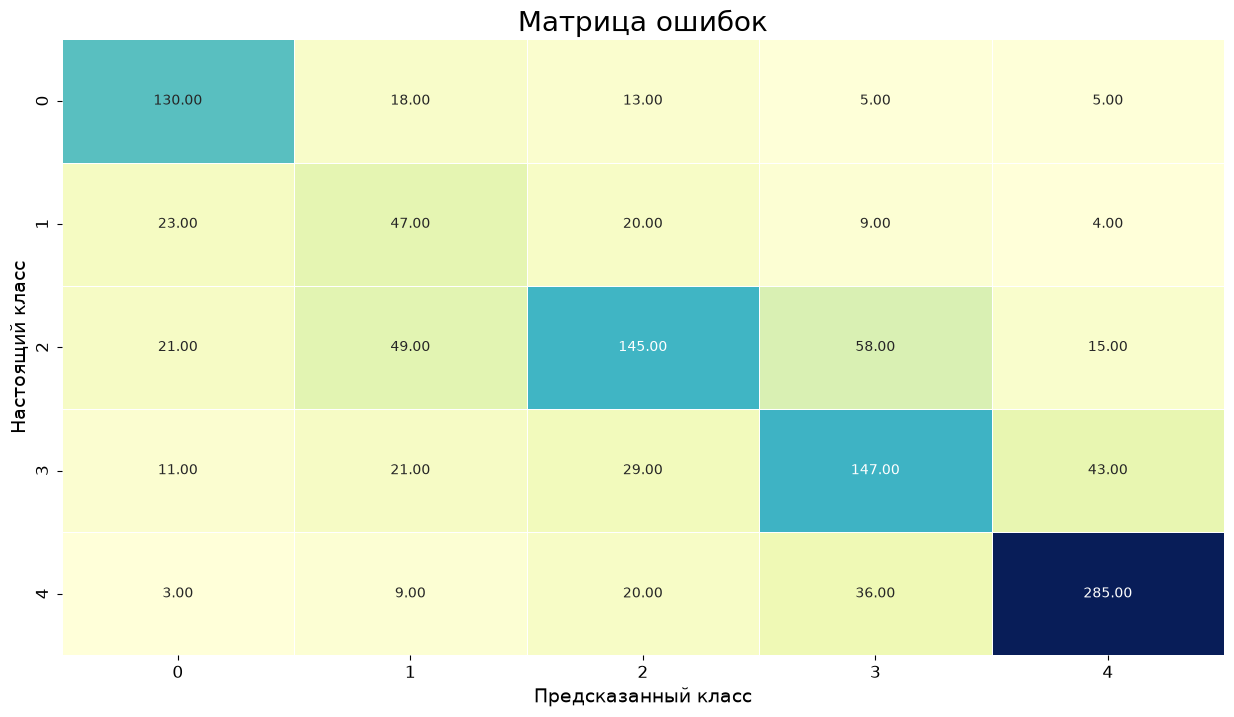

In [79]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(15,8))
fig = sns.heatmap(cm, 
                annot=True,     # Отображаем численные значения в ячейках карты
                fmt='.2f',      # Форматируем значения корреляции: два знака после точки
                cmap='YlGnBu',  # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                linewidths=0.5, # Форматируем линию между ячейками карты
                cbar=False,     # Отключаем цветовую шкалу
                annot_kws={'size': 10}
                )
plt.title('Матрица ошибок', fontsize=20)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.ylabel('Настоящий класс', fontsize=14)
fig.tick_params(axis='both', labelsize=12)
plt.show() 

<span style="font-size: 18px;">**Выводы**</span>

Исходя из более подробного отчета по метрикам и визуальных данных можно прийти к следующим выводам:
- Финальная модель значительно превзошла базовую модеь - `Dummy_Model` как по основной метрики `F1_macro` (прирост показателя около 7 раз), так и по `Precision_macro` (около 10 раз) и `Recall_macro` (более 3 раз). Общая точность выросла более чем в 2 раза и составила около 65%, что говорит о том, что финальная модель верно определяет класс около 65% случаев. 
- Однако, к сожелению, финальная модель не может быть рекомендована к внедрению, т.к. не достигла показателя по ключевой метрики `F1_macro` в 0.75 (её показатели около 0.62 валидационной и тестовой выборке). Рассмотрим более подробно какие классы (возростные группы) для модели являются проблемными, а с какими группами модель справляется отлично:
    - Класс 4, возраст 56+, самый многочисленный, при этом модель лучше всего определяет возраст в этой возрастной группе и проходит требуемые показатели качества. В 81% случаев, если модель утверждает, что человек принадлежит этой возрастной группе, то он действительно принадлежит этой группе (`Precision` $\approx$ 0.81). Кроме того, из всей выборке людей в этой группе модель находит 81%, что тоже хороший показатель. 
    - Класс 0, возраст до 18 лет, модель обладает хорошим охватом и находит около 76% всех пользователей. Однако, точно не столь высока и только в 69% случаев возраст пользователя действительно меньше 18 лет. Эта группа имеет мельнький охват (вторая снизу по количеству людей в ней).
    - Проблемным классом (1) для модели является наименьший класс по количеству людей (18–25 лет), она приблизительно одинаково часто говорит, что человек попадает в соседние классы по возрасту (или меньше 18 или ему 26-40 лет).
    - В оставшихся двух классах 2 (26–40 лет) и 3 (41–55 лет) модель также испытывает некоторые трудности и тоже часто путает соседние классы между собой, например, человек в возрасте от 26–40, говорит, что ему или от 18 до 25 или от 41 до 55. Общее качество в этих группах также не достигает требуемого уровня по `f1` (`f1_macro` - обычное усреднение всех показателей `f1` по всем возростным группам, поэтому важно, чтобы как можно больше классов привышало уровень в 0.75).
- В качестве рекомендаций по улучшению качества модели могу предложить следующее:
    - Добавить дополнительные признаки, которые помогли бы модели более четко различать людей в возрасте от 18 и до 55 лет. Возможно, чуть менее катигорично объединять сайты в 20 категорий и увеличит количество категорий. Некоторые примеры: возраст устройства (год выпуска / модель устройства) для подключения, география (страна, регион, город), поисковые запросы (категории запросов или обезличенные темы), длительность сессий (средняя/медианная продолжительность), время регистрации аккаунта. 
    - Возможно, требуется более аккуратный отсев по сравнению с тем что был сделан, а также создание из уже имеющихся данных новых признаков. Например, не просто доли для наимении и наболее частой категории сайтов, а доли для всех категорий, т.е. рассматриваем не только минимум и максимум, а вообще все.
    - Использовать более сложные, не линейные по признакам модели или другие подходы. Возможно, засчет использования других, более сложных моделей требуемое качество получится достигнуть.

---

<a id='p7'></a>

## Подготовка артефактов модели

[К Содержимому проекта](#contents)

In [80]:
# Для GitHub
joblib.dump(final_model, './../models/age_group_predict_model.joblib')

# joblib.dump(final_model, 'age_group_predict_model.joblib')

# Для GitHub
loaded_model = joblib.load('./../models/age_group_predict_model.joblib')
# loaded_model = joblib.load('age_group_predict_model.joblib')

y_pred = loaded_model.predict(X_test)

metrics_df = pd.DataFrame([
    Metrics_Calc_Simple_Est(loaded_model, X_test, y_test, need_fit = False, model_name = 'SVC_non_linear', fold_name = 'test')
])
metrics_df = metrics_df.round(4)

display(metrics_df)

,model_name,fold_name,F1_macro,Precision_macro,Recall_macro,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
0,SVC_non_linear,test,0.6115,0.6086,0.6226,0.6467,0.6488,0.6572,0.6467


---

<a id='p8'></a>

## Выводы о результатах работы

[К Содержимому проекта](#contents)

<span style="font-size: 18px;">**1. Цель и контекст**</span>

Задача - многоклассовая классификация пользователей по пяти возрастным группам (`0` - до 18, `1` - 18-25, `2` - 26-40, 3 - 41-55, `4` - 56+) на основе данных о цифровом поведении. Бизнес-цель - точный рекламный таргетинг, особое внимание к классу несовершеннолетних. Основная метрика - `F1 macro`, порог качества $\ge$ 0.75. Исходные данные объединены из нескольких таблиц по `user_id`.

<span style="font-size: 18px;">**2. Проделанная работа и ключевые результаты**</span>

- Проведён EDA, данные агрегированы до 5826 пользователей и 18 признаков. Обнаружен дисбаланс классов.
- Созданы признаки из логов посещений: частота сессий, доли по категориям сайтов и времени суток, активность по рекламе и устройствам. Удалены неинформативные и линейно зависимые признаки.
- Все преобразования включены в пайплайн для предотвращения утечки.
- Базовый `DummyClassifier` дал `F1 macro` $\approx$ 0.09.
- После отбора признаков (методы обёртки + L1-регуляризация) и подбора гиперпараметров лучшей стала `SVC с RBF-ядром`.
- Итоговые метрики на тесте: `F1 macro` $\approx$ 0.62, `Precision macro` $\approx$ 0.66, `Recall macro` $\approx$ 0.59, `Accuracy` $\approx$ 0.65. Модель в ~7 раз лучше базовой, но не достигает порога 0.75.
- Артефакты (модель, пайплайн, функция объединения) сохранены и проверены на воспроизводимость.

<span style="font-size: 18px;">**3. Анализ факторов, влияющих на возрастную категорию**</span>

- Наиболее значимые признаки:
    - Категории наиболее и наименее посещаемых сайтов - ключевой блок.
    - Активность взаимодействия с рекламой и глубина просмотра.
    - Основное устройство и использование облака.
    - Доли активности по времени суток.
- Качество по классам:
    - Класс 4 (56+) - определяется хорошо (Precision $\approx$ 0.81, Recall $\approx$ 0.81).
    - Класс 0 (до 18) - Recall $\approx$ 0.76, но Precision $\approx$ 0.69: часть взрослых ошибочно попадает в эту группу.
    - Класс 1 (18–25) - самый проблемный: путается с соседними классами 0 и 2.
    - Классы 2 и 3 - систематически смешиваются между собой и с соседними.
- Основная трудность - различение смежных возрастных групп в середине диапазона.

<span style="font-size: 18px;">**4. Выводы и рекомендации**</span>

Модель не достигла требуемого порога `F1 macro` $\ge$ 0.75 и в текущем виде не рекомендуется к внедрению. Для улучшения предлагается:
- Расширить признаки: использовать доли всех категорий сайтов (не только max/min), добавить длительность сессий, число уникальных дней, географию, параметры устройства.
- Пересмотреть отбор признаков и добавить нелинейные преобразования.
- Использовать модели с нелинейной взаимосвязью признаков или другие методы.
- Применить балансировку классов для улучшения распознавания редких классов.
- Детальнее изучить ошибки между соседними возрастными группами - возможно, пересмотреть границы классов.

**Итог:** проект выполнен в полном объёме с точки зрения исследовательского процесса, получена рабочая модель с качеством выше случайного, но для production-использования требуется доработка с учётом предложенных рекомендаций.

Ссылка для скачивания проекта, в том числе модели:

https://github.com/AlexandrEvdokimov/Classification-of-age-groups-of-Yeti-users.git